<a href="https://colab.research.google.com/github/fourmodern/2026_aidrugdiscovery/blob/main/Day06_LLM_Agent/t110_esm2_peptide_optimization_tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ESM-2로 펩타이드 결합자 설계하고 최적화하기

**Day 06 · 단백질 언어모델 실습**

단백질 언어모델 ESM-2(PepMLM)에게 표적 단백질 **PDE5A** 를 보여 주고 결합할 만한 15-mer 펩타이드를
생성시킨 뒤, pseudo-perplexity 로 순위를 매기고 EvoProtGrad 로 in silico 방향진화까지 돌려 본다.


## 0. 실행 환경

- **GPU 권장, CPU도 가능.** Colab: 런타임 > 런타임 유형 변경 > T4 GPU.
- 내려받는 모델
  - `ChatterjeeLab/PepMLM-650M` (약 2.6GB) — gated 아님, HF 로그인 불필요
  - `facebook/esm2_t6_8M_UR50D` (약 30MB) — EvoProtGrad 전문가 모델
- 예상 소요 시간: GPU 3~5분 / CPU 8~12분 (대부분 모델 다운로드 시간)
- 아래 셀이 필요한 패키지를 먼저 확인해 **없는 것만** 설치하고, 연산 장치를 `DEVICE` 상수 하나로 고정합니다.
  이후 모든 셀은 `DEVICE` 만 참조합니다.
- PyPI의 `esm` 패키지는 **ESM-2가 아니라 ESM3**(EvolutionaryScale)이므로 여기서는 설치하지 않습니다.
  ESM-2 계열 가중치는 Hugging Face Hub에서 `transformers` 로 직접 불러옵니다
  (ESM3 실습은 `t111_esm3_protein_design.ipynb` 참고).


In [1]:
import importlib, subprocess, sys

REQUIRED = {
    # "import 이름": "pip 패키지명"
    "transformers": "transformers",      # ESM-2 / PepMLM 가중치와 토크나이저
    "seaborn": "seaborn",                # 그림 스타일
    "Bio": "biopython",                  # 그림 7 물성 계산 (ProteinAnalysis)
    "logomaker": "logomaker",            # 그림 4 서열 로고
}

def ensure(packages: dict) -> list:
    """import 가능한지 먼저 확인하고, 없는 것만 pip로 설치한다."""
    missing = [pip_name for mod, pip_name in packages.items()
               if importlib.util.find_spec(mod) is None]
    if missing:
        print("설치 대상:", ", ".join(missing))
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)
    else:
        print("모든 의존 패키지가 이미 준비되어 있습니다.")
    return missing

ensure(REQUIRED)


import torch

# 연산 장치는 이 상수 하나로 고정한다 (노트북 전체에서 DEVICE 만 사용)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("PyTorch:", torch.__version__)
print("DEVICE =", DEVICE)
if DEVICE == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("[안내] CPU 런타임입니다. 실행은 되지만 느립니다 "
          "(binder 1개당 약 40초, 5개면 3~4분).")


모든 의존 패키지가 이미 준비되어 있습니다.


PyTorch: 2.13.0+cpu
DEVICE = cpu
[안내] CPU 런타임입니다. 실행은 되지만 느립니다 (binder 1개당 약 40초, 5개면 3~4분).


## 1. 개요와 학습 목표

- **표적**: PDE5A (phosphodiesterase type 5A; UniProt **O76074**, canonical 875 aa).
  실데나필·타다라필 같은 PDE5 저해제가 붙는 바로 그 단백질이다.
- **생성**: PepMLM(ESM-2 650M 기반)에게 표적 서열 뒤에 `<mask>` 15개를 붙여 주고,
  masked language modeling 으로 결합자 후보 15-mer 를 뽑는다.
- **순위**: pseudo-perplexity(PPL)로 후보를 정렬한다. PPL 이 낮을수록 모델이
  "단백질스럽다"고 보는 서열이며, **결합력(Kd/IC50)의 예측치가 아니다.**
- **최적화**: EvoProtGrad 로 gradient 기반 discrete MCMC 방향진화를 돌려,
  표적과 링커는 고정한 채 15-mer 만 변이시킨다.
- **확인**: 그림 7장으로 모델 내부 확률, 순위, 조성 편향, 변이 위치, 물성 공간을 눈으로 검증한다.


## 2. 모델과 표적 준비

PepMLM 가중치를 내려받고, 표적 서열과 그림 공통 서식을 준비한다.


### 2-1. PepMLM (ESM-2 650M) 모델 로드

Hugging Face Hub 의 사전학습 ESM-2 계열 모델을 씁니다. ESM-2 는 단백질 서열을 이해하도록
학습되어 있어 표적과 펩타이드의 상호작용을 예측하는 데 적합합니다.
(PepMLM 저장소가 `TianlaiChen` 에서 `ChatterjeeLab` 으로 이전되었습니다.)


In [2]:
# PepMLM (ESM-2 650M 기반) 모델과 토크나이저 로드
from transformers import AutoTokenizer, AutoModelForMaskedLM
import torch
import pandas as pd
import numpy as np
from torch.distributions import Categorical

# Load the pre-trained ESM-2(PepMLM) model and tokenizer from Hugging Face
# 가중치 약 2.6GB. 라이선스 동의/로그인 불필요(gated 아님). 첫 실행 시 다운로드에 수 분 소요.
model = AutoModelForMaskedLM.from_pretrained("ChatterjeeLab/PepMLM-650M").to(DEVICE).eval()
tokenizer = AutoTokenizer.from_pretrained("ChatterjeeLab/PepMLM-650M")

print("모델/토크나이저 로드 완료. model.device =", model.device)

/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/540 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 540/540 [00:00<00:00, 32976.01it/s]

모델/토크나이저 로드 완료. model.device = cpu


### 2-2. 표적 단백질 서열 준비

표적은 PDE5A(UniProt O76074, canonical 875 aa)입니다. 서열을 토크나이즈해 모델 입력 형태를 확인합니다.


In [3]:
# 표적 단백질 서열 준비
# 표적 단백질: PDE5A (PDE5 저해제 sildenafil/tadalafil의 표적) - UniProt O76074, canonical 875 aa
protein_seq = "MERAGPSFGQQRQQQQPQQQKQQQRDQDSVEAWLDDHWDFTFSYFVRKATREMVNAWFAERVHTIPVCKEGIRGHTESCSCPLQQSPRADNSAPGTPTRKISASEFDRPLRPIVVKDSEGTVSFLSDSEKKEQMPLTPPRFDHDEGDQCSRLLELVKDISSHLDVTALCHKIFLHIHGLISADRYSLFLVCEDSSNDKFLISRLFDVAEGSTLEEVSNNCIRLEWNKGIVGHVAALGEPLNIKDAYEDPRFNAEVDQITGYKTQSILCMPIKNHREEVVGVAQAINKKSGNGGTFTEKDEKDFAAYLAFCGIVLHNAQLYETSLLENKRNQVLLDLASLIFEEQQSLEVILKKIAATIISFMQVQKCTIFIVDEDCSDSFSSVFHMECEELEKSSDTLTREHDANKINYMYAQYVKNTMEPLNIPDVSKDKRFPWTTENTGNVNQQCIRSLLCTPIKNGKKNKVIGVCQLVNKMEENTGKVKPFNRNDEQFLEAFVIFCGLGIQNTQMYEAVERAMAKQMVTLEVLSYHASAAEEETRELQSLAAAVVPSAQTLKITDFSFSDFELSDLETALCTIRMFTDLNLVQNFQMKHEVLCRWILSVKKNYRKNVAYHNWRHAFNTAQCMFAALKAGKIQNKLTDLEILALLIAALSHDLDHRGVNNSYIQRSEHPLAQLYCHSIMEHHHFDQCLMILNSPGNQILSGLSIEEYKTTLKIIKQAILATDLALYIKRRGEFFELIRKNQFNLEDPHQKELFLAMLMTACDLSAITKPWPIQQRIAELVATEFFDQGDRERKELNIEPTDLMNREKKNKIPSMQVGFIDAICLQLYEALTHVSEDCFPLLDGCRKNRQKWQALAEQQEKMLINGESGQAKRN"

# Tokenize the protein sequence for the model
inputs = tokenizer(protein_seq, return_tensors="pt")

print("Protein sequence tokenized.")
print("Inputs:", inputs)


Protein sequence tokenized.
Inputs: {'input_ids': tensor([[ 0, 20,  9, 10,  5,  6, 14,  8, 18,  6, 16, 16, 10, 16, 16, 16, 16, 14,
         16, 16, 16, 15, 16, 16, 16, 10, 13, 16, 13,  8,  7,  9,  5, 22,  4, 13,
         13, 21, 22, 13, 18, 11, 18,  8, 19, 18,  7, 10, 15,  5, 11, 10,  9, 20,
          7, 17,  5, 22, 18,  5,  9, 10,  7, 21, 11, 12, 14,  7, 23, 15,  9,  6,
         12, 10,  6, 21, 11,  9,  8, 23,  8, 23, 14,  4, 16, 16,  8, 14, 10,  5,
         13, 17,  8,  5, 14,  6, 11, 14, 11, 10, 15, 12,  8,  5,  8,  9, 18, 13,
         10, 14,  4, 10, 14, 12,  7,  7, 15, 13,  8,  9,  6, 11,  7,  8, 18,  4,
          8, 13,  8,  9, 15, 15,  9, 16, 20, 14,  4, 11, 14, 14, 10, 18, 13, 21,
         13,  9,  6, 13, 16, 23,  8, 10,  4,  4,  9,  4,  7, 15, 13, 12,  8,  8,
         21,  4, 13,  7, 11,  5,  4, 23, 21, 15, 12, 18,  4, 21, 12, 21,  6,  4,
         12,  8,  5, 13, 10, 19,  8,  4, 18,  4,  7, 23,  9, 13,  8,  8, 17, 13,
         15, 18,  4, 12,  8, 10,  4, 18, 13,  7,  5,  9,  6

### 2-3. 그림 공통 설정

이후 그림 7장이 공유할 팔레트·해상도·아미노산 정렬 순서를 여기서 한 번만 정합니다.
축 라벨과 범례는 Colab 기본 폰트에 한글 글리프가 없어 **영문**으로 쓰고, 설명은 각 그림 위 마크다운(한글)에 둡니다.


In [4]:
# === 시각화 공통 설정 (visualization setup) ===
# 그래프의 라벨/제목/범례는 전부 영문입니다.
# Colab 기본 matplotlib 폰트에는 한글 글리프가 없어 한글을 쓰면 □□□ 로 깨집니다.
# 설명은 각 그림 바로 위의 마크다운 셀(한글)에 있습니다.
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Patch

try:
    import seaborn as sns          # 있으면 스타일만 빌려 씁니다(없어도 동작).
    sns.set_theme(style="white", context="paper")
except Exception:
    sns = None

# BioPython (그림 7 물성 계산용) — 0절 ensure(REQUIRED) 가 이미 설치를 보장한다
from Bio.SeqUtils.ProtParam import ProteinAnalysis

plt.rcParams.update({
    "figure.dpi": 300,          # 노트북에 임베드되는 그림 = 300 DPI
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "figure.facecolor": "white",
    "savefig.facecolor": "white",
    "font.family": "DejaVu Sans",
    "font.size": 7,
    "axes.titlesize": 8,
    "axes.labelsize": 7.5,
    "legend.fontsize": 6.5,
    "xtick.labelsize": 6.5,
    "ytick.labelsize": 6.5,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
})

# Okabe-Ito: 색각 이상(colorblind)에서도 구분되는 표준 팔레트
OK = {"blue": "#0072B2", "orange": "#E69F00", "green": "#009E73",
      "vermillion": "#D55E00", "skyblue": "#56B4E9", "yellow": "#F0E442",
      "purple": "#CC79A7", "grey": "#8C8C8C", "black": "#000000"}

# 아미노산을 물리화학적 성질로 묶어 정렬 (히트맵/로고에서 패턴이 보이게)
AA_GROUPS = [
    ("Hydrophobic", list("AVLIMFWC"), OK["blue"]),
    ("Gly / Pro",   list("GP"),       OK["grey"]),
    ("Polar",       list("STNQY"),    OK["green"]),
    ("Positive",    list("KRH"),      OK["vermillion"]),
    ("Negative",    list("DE"),       OK["purple"]),
]
AA_ORDER = [a for _, aas, _ in AA_GROUPS for a in aas]        # 20종
AA_COLOR = {a: c for _, aas, c in AA_GROUPS for a in aas}
AA_INDEX = {a: i for i, a in enumerate(AA_ORDER)}
assert len(AA_ORDER) == 20

PEPTIDE_LENGTH = 15   # 노트북 전체에서 쓰는 binder 길이 (4-2절과 동일)
TOP_K = 3             # generate_peptide(top_k=3) 와 동일

print("visualization setup ready |", len(AA_ORDER), "amino acids |",
      "seaborn:", sns is not None)
print("NOTE: 펩타이드 생성은 확률적(top-k sampling)이라 실행할 때마다 그림이 조금씩 달라집니다.")


visualization setup ready | 20 amino acids | seaborn: True
NOTE: 펩타이드 생성은 확률적(top-k sampling)이라 실행할 때마다 그림이 조금씩 달라집니다.


## 3. 마스크 위치별 아미노산 확률 (그림 1)

PepMLM 은 표적 서열 뒤에 `<mask>` 15개를 붙여 놓고 **각 자리에 어떤 아미노산이 올지**를 동시에 예측합니다.
아래 히트맵은 그 예측 확률(15개 위치 × 20종 아미노산)을 그대로 그린 것입니다 — **모델이 펩타이드를 "만드는" 순간의 내부 상태**입니다.

- **읽는 법**: 세로축은 아미노산(물리화학적 성질로 묶음), 가로축은 펩타이드 1~15번 자리. 밝을수록 확률이 높습니다.
  각 열의 상위 3개 후보에 글자를 찍고 1위는 주황 테두리로 표시했습니다(top-k=3 샘플링이 고르는 후보군).
- **아래 막대**는 위치별 엔트로피(bits)입니다. 낮을수록 모델이 그 자리에 확신이 있고, 높을수록(최대 4.32) 아무거나 넣어도 된다는 뜻입니다.

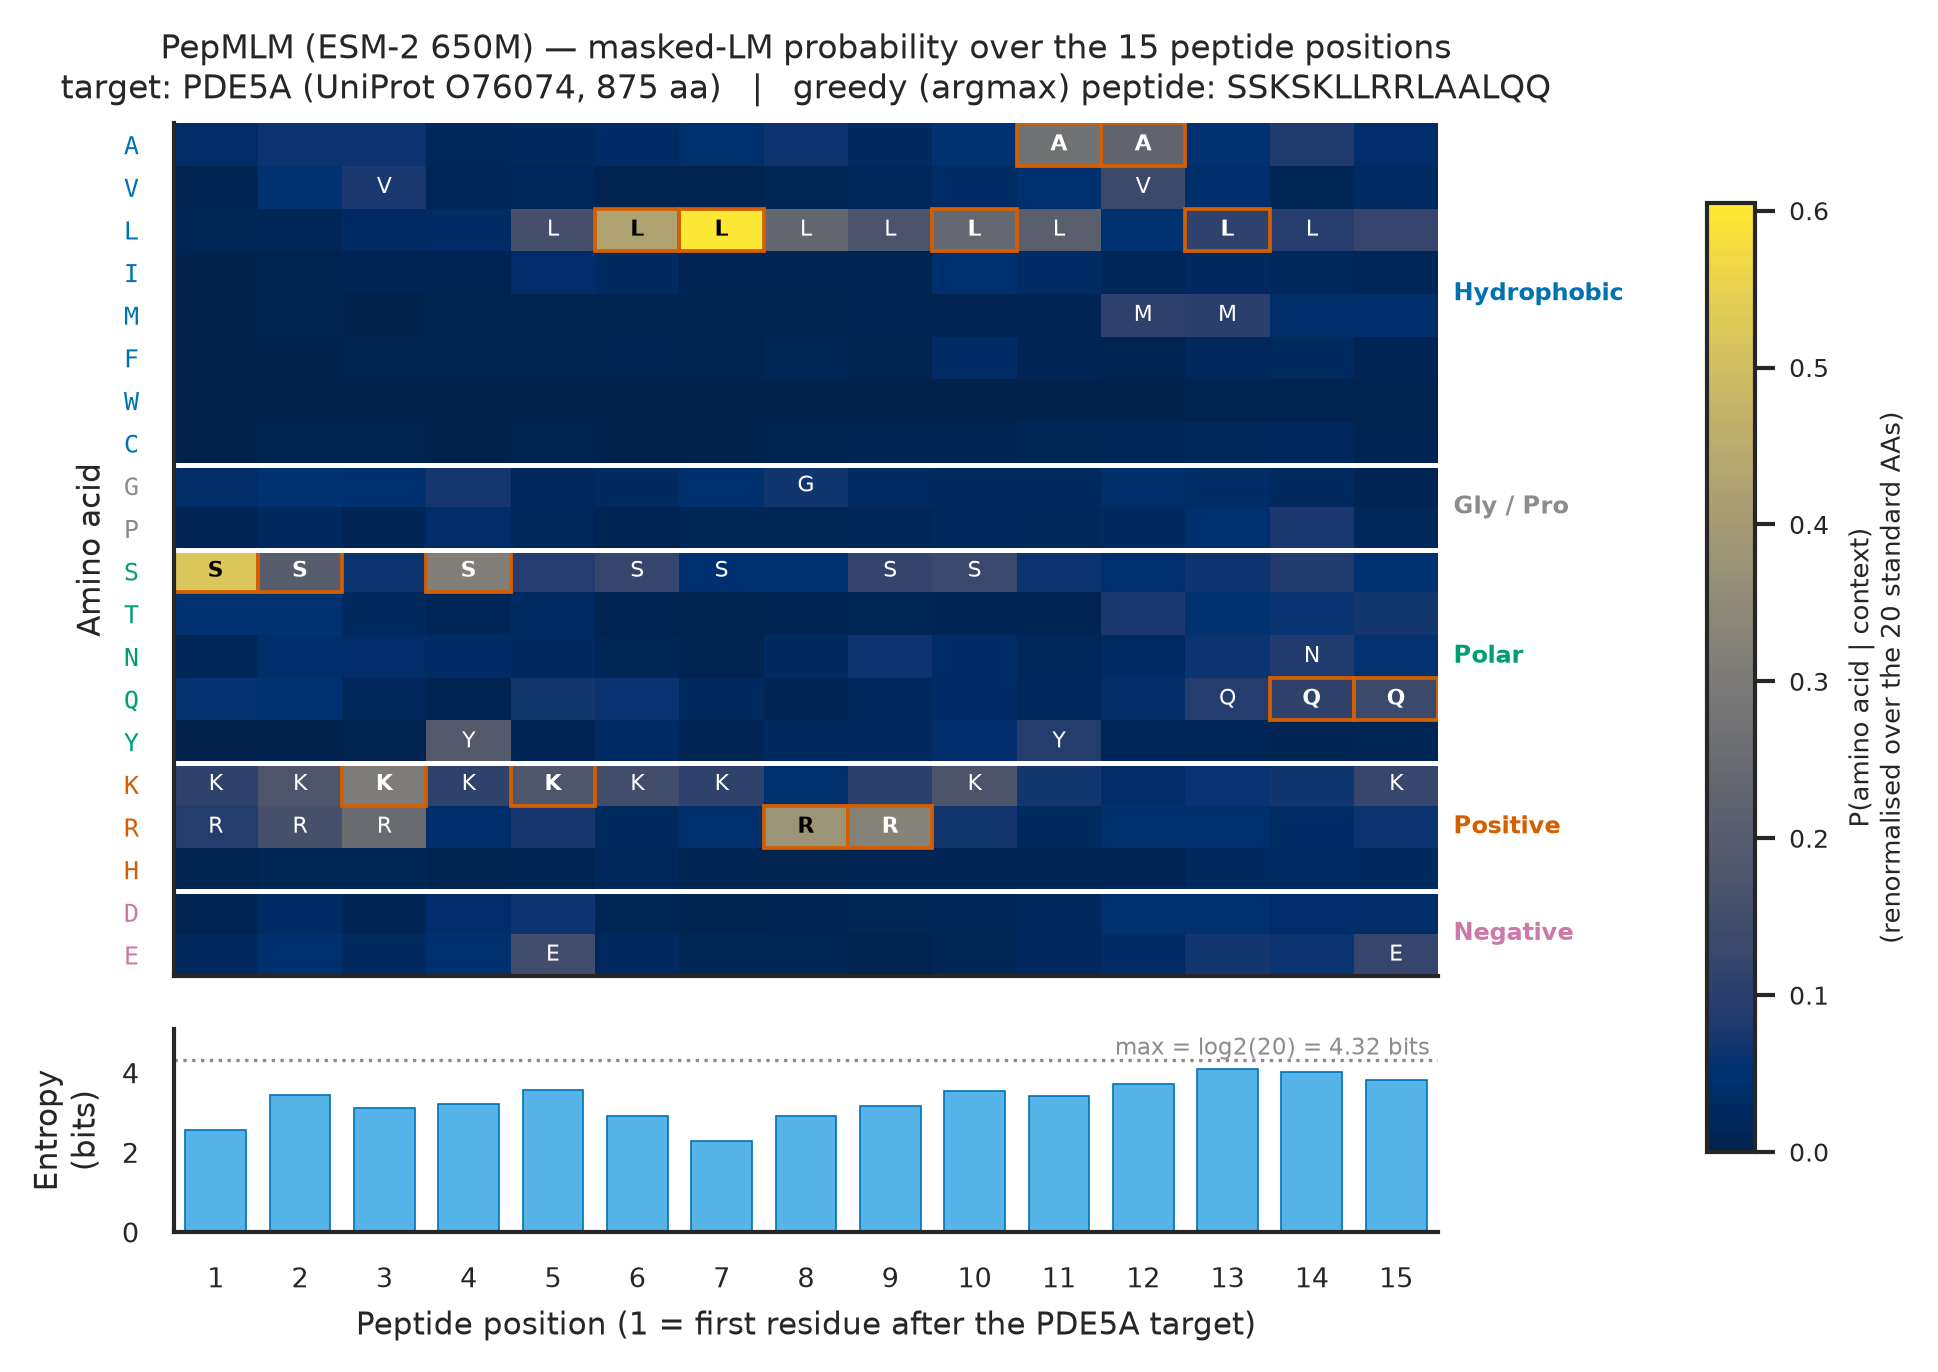

greedy (argmax) peptide : SSKSKLLRRLAALQQ
mean entropy            : 3.32 bits (max 4.32)


In [5]:
# === Figure 1. per-position amino-acid probability at the 15 masked sites ===
# generate_peptide_for_single_sequence() 가 내부에서 하는 것과 완전히 동일한 forward pass 입니다.
masked_peptide = "<mask>" * PEPTIDE_LENGTH
mask_inputs = tokenizer(protein_seq + masked_peptide, return_tensors="pt").to(model.device)
with torch.no_grad():
    mask_logits_full = model(**mask_inputs).logits

mask_positions = (mask_inputs["input_ids"][0] == tokenizer.mask_token_id).nonzero(as_tuple=True)[0]
logits_at_masks = mask_logits_full[0, mask_positions].float()          # (15, vocab)

aa_token_ids = [tokenizer.convert_tokens_to_ids(a) for a in AA_ORDER]
P = torch.softmax(logits_at_masks, dim=-1)[:, aa_token_ids].cpu().numpy()   # (15, 20)
P = P / P.sum(axis=1, keepdims=True)      # 특수 토큰 확률을 빼고 20종으로 재정규화

greedy_peptide = "".join(AA_ORDER[int(i)] for i in P.argmax(axis=1))
entropy_bits = -(P * np.log2(np.clip(P, 1e-12, None))).sum(axis=1)

fig, (ax, axe) = plt.subplots(
    2, 1, figsize=(6.8, 4.8), sharex=True,
    gridspec_kw={"height_ratios": [4.2, 1.0], "hspace": 0.10})

im = ax.imshow(P.T, aspect="auto", cmap="cividis", vmin=0.0, origin="upper")

# 상위 3개 후보에 아미노산 글자, 1위에는 테두리
vmax = P.max()
for j in range(PEPTIDE_LENGTH):
    for rank, i in enumerate(np.argsort(P[j])[::-1][:3]):
        ax.text(j, i, AA_ORDER[i], ha="center", va="center", fontsize=5.2,
                fontweight="bold" if rank == 0 else "normal",
                color="black" if P[j, i] > 0.55 * vmax else "white")
    top1 = int(P[j].argmax())
    ax.add_patch(Rectangle((j - .5, top1 - .5), 1, 1, fill=False,
                           edgecolor=OK["vermillion"], lw=0.9))

# 아미노산 그룹 경계선 + 그룹 라벨
b = 0
for name, aas, col in AA_GROUPS:
    b += len(aas)
    if b < 20:
        ax.axhline(b - 0.5, color="white", lw=1.2)
    ax.text(1.012, b - len(aas) / 2 - 0.5, name, va="center", ha="left",
            fontsize=5.8, color=col, fontweight="bold",
            transform=ax.get_yaxis_transform(), clip_on=False)

ax.set_yticks(range(20))
ax.set_yticklabels(AA_ORDER, fontfamily="monospace", fontsize=6)
for t, a in zip(ax.get_yticklabels(), AA_ORDER):
    t.set_color(AA_COLOR[a])
ax.set_ylabel("Amino acid")
ax.set_title("PepMLM (ESM-2 650M) — masked-LM probability over the 15 peptide positions\n"
             f"target: PDE5A (UniProt O76074, 875 aa)   |   greedy (argmax) peptide: {greedy_peptide}")
cb = fig.colorbar(im, ax=[ax, axe], fraction=0.030, pad=0.17)
cb.set_label("P(amino acid | context)\n(renormalised over the 20 standard AAs)", fontsize=6.2)
cb.ax.tick_params(labelsize=6)

axe.bar(np.arange(PEPTIDE_LENGTH), entropy_bits, color=OK["skyblue"],
        edgecolor=OK["blue"], lw=0.4, width=0.72)
axe.axhline(np.log2(20), color=OK["grey"], ls=":", lw=0.8)
axe.text(PEPTIDE_LENGTH - 0.6, np.log2(20), " max = log2(20) = 4.32 bits",
         fontsize=5.5, va="bottom", ha="right", color=OK["grey"])
axe.set_ylim(0, np.log2(20) * 1.18)
axe.set_ylabel("Entropy\n(bits)")
axe.set_xlabel("Peptide position (1 = first residue after the PDE5A target)")
axe.set_xticks(range(PEPTIDE_LENGTH))
axe.set_xticklabels(range(1, PEPTIDE_LENGTH + 1))

plt.show()
print("greedy (argmax) peptide :", greedy_peptide)
print("mean entropy            : %.2f bits (max 4.32)" % entropy_bits.mean())


## 4. 펩타이드 생성과 순위 매기기

마스크 확률에서 실제로 후보 서열을 뽑고, pseudo-perplexity 로 줄을 세운 뒤
무엇이 뽑혔는지를 조성·로고로 확인한다.


### 4-1. 생성 함수 정의

PepMLM 의 masked language modeling 으로 표적에 결합할 만한 펩타이드를 만드는 함수와,
그 서열의 pseudo-perplexity 를 재는 함수를 정의합니다.


In [6]:

def compute_pseudo_perplexity(model, tokenizer, protein_seq, binder_seq):
    """binder 잔기를 하나씩 마스킹해 복원 난이도를 재고 pseudo-perplexity 를 돌려준다."""
    sequence = protein_seq + binder_seq
    original_input = tokenizer.encode(sequence, return_tensors='pt').to(model.device)
    length_of_binder = len(binder_seq)

    # Prepare a batch with each row having one masked token from the binder sequence
    masked_inputs = original_input.repeat(length_of_binder, 1)
    positions_to_mask = torch.arange(-length_of_binder - 1, -1, device=model.device)

    masked_inputs[torch.arange(length_of_binder), positions_to_mask] = tokenizer.mask_token_id

    # Prepare labels for the masked tokens
    labels = torch.full_like(masked_inputs, -100)
    labels[torch.arange(length_of_binder), positions_to_mask] = original_input[0, positions_to_mask]

    # Get model predictions and calculate loss
    with torch.no_grad():
        outputs = model(masked_inputs, labels=labels)
        loss = outputs.loss

    # Loss is already averaged by the model
    avg_loss = loss.item()
    pseudo_perplexity = np.exp(avg_loss)
    return pseudo_perplexity


def generate_peptide_for_single_sequence(protein_seq, peptide_length = 15, top_k = 3, num_binders = 4):
    """표적 서열 하나에 대해 top-k 샘플링으로 결합자 후보와 그 PPL 목록을 만든다."""

    peptide_length = int(peptide_length)
    top_k = int(top_k)
    num_binders = int(num_binders)

    binders_with_ppl = []

    for _ in range(num_binders):
        # Generate binder
        masked_peptide = '<mask>' * peptide_length
        input_sequence = protein_seq + masked_peptide
        inputs = tokenizer(input_sequence, return_tensors="pt").to(model.device)

        with torch.no_grad():
            logits = model(**inputs).logits
        mask_token_indices = (inputs["input_ids"] == tokenizer.mask_token_id).nonzero(as_tuple=True)[1]
        logits_at_masks = logits[0, mask_token_indices]

        # Apply top-k sampling
        top_k_logits, top_k_indices = logits_at_masks.topk(top_k, dim=-1)
        probabilities = torch.nn.functional.softmax(top_k_logits, dim=-1)
        predicted_indices = Categorical(probabilities).sample()
        predicted_token_ids = top_k_indices.gather(-1, predicted_indices.unsqueeze(-1)).squeeze(-1)

        generated_binder = tokenizer.decode(predicted_token_ids, skip_special_tokens=True).replace(' ', '')

        # Compute PPL for the generated binder
        ppl_value = compute_pseudo_perplexity(model, tokenizer, protein_seq, generated_binder)

        # Add the generated binder and its PPL to the results list
        binders_with_ppl.append([generated_binder, ppl_value])

    return binders_with_ppl

def generate_peptide(input_seqs, peptide_length=15, top_k=3, num_binders=4):
    """서열 하나 또는 여러 개를 받아 후보 결합자와 PPL 을 DataFrame 으로 돌려준다."""
    if isinstance(input_seqs, str):  # Single sequence
        binders = generate_peptide_for_single_sequence(input_seqs, peptide_length, top_k, num_binders)
        return pd.DataFrame(binders, columns=['Binder', 'Pseudo Perplexity'])

    elif isinstance(input_seqs, list):  # List of sequences
        results = []
        for seq in input_seqs:
            binders = generate_peptide_for_single_sequence(seq, peptide_length, top_k, num_binders)
            for binder, ppl in binders:
                results.append([seq, binder, ppl])
        return pd.DataFrame(results, columns=['Input Sequence', 'Binder', 'Pseudo Perplexity'])

### 4-2. 후보 생성과 pseudo-perplexity 순위

위에서 정의한 함수로 15-mer 펩타이드 후보를 top-k 샘플링으로 여러 개 만들고,
**pseudo-perplexity (PPL)** 로 순위를 매깁니다.
PPL은 binder의 각 잔기를 하나씩 마스킹해 모델이 원래 잔기를 얼마나 잘 복원하는지를 재는 값으로,
**낮을수록** 모델이 그 서열을 "그럴듯하다"고 본다는 뜻입니다.
(주의: PPL은 실제 결합 친화도(Kd/IC50)의 예측치가 아닙니다. 실험 검증이 반드시 필요합니다.)

In [7]:
# 실행 시간 안내:
#  - GPU(T4): 전체 5개 binder 생성에 약 20~30초
#  - CPU    : binder 1개당 약 40초 (5개면 3~4분). 느리면 num_binders를 2로 줄이세요.
results_df = generate_peptide(protein_seq, peptide_length=15, top_k=3, num_binders=5)
print(results_df.sort_values("Pseudo Perplexity").to_string(index=False))
print()
print("Pseudo-perplexity(PPL)가 낮을수록 ESM-2가 '그럴듯하다'고 보는 서열입니다.")
print("주의: PPL은 결합력(Kd)의 직접 예측치가 아니라 언어모델 관점의 서열 그럴듯함 지표입니다.")

         Binder  Pseudo Perplexity
SKKSEKLRLKAMQNK           9.325864
SKKYESLRRLAAQNE          11.302991
SKRSLLLRRLAVQNE          12.920282
SKRKELLLRLLALNQ          13.725989
SSVYLLLRRSAVQLQ          27.429950

Pseudo-perplexity(PPL)가 낮을수록 ESM-2가 '그럴듯하다'고 보는 서열입니다.
주의: PPL은 결합력(Kd)의 직접 예측치가 아니라 언어모델 관점의 서열 그럴듯함 지표입니다.


### 4-3. 그림 2. 후보 펩타이드의 pseudo-perplexity 순위

위 표(`results_df`)를 그림으로 옮긴 것입니다. 막대가 **짧을수록** 모델이 그 서열을 그럴듯하다고 본다는 뜻입니다.

- **읽는 법**: 1위(가장 낮은 PPL)를 주황색으로 강조했습니다. 같은 프롬프트에서 top-k 샘플링만 다르게 했는데도
  PPL 이 몇 배씩 벌어지는 것을 볼 수 있습니다 — 즉 **여러 개 뽑아서 고르는 과정(ranking)** 이 필요합니다.
- **주의**: PPL 은 결합력(Kd/IC50) 예측치가 **아닙니다**. 언어모델이 보기에 "단백질스러운가"를 재는 값입니다.

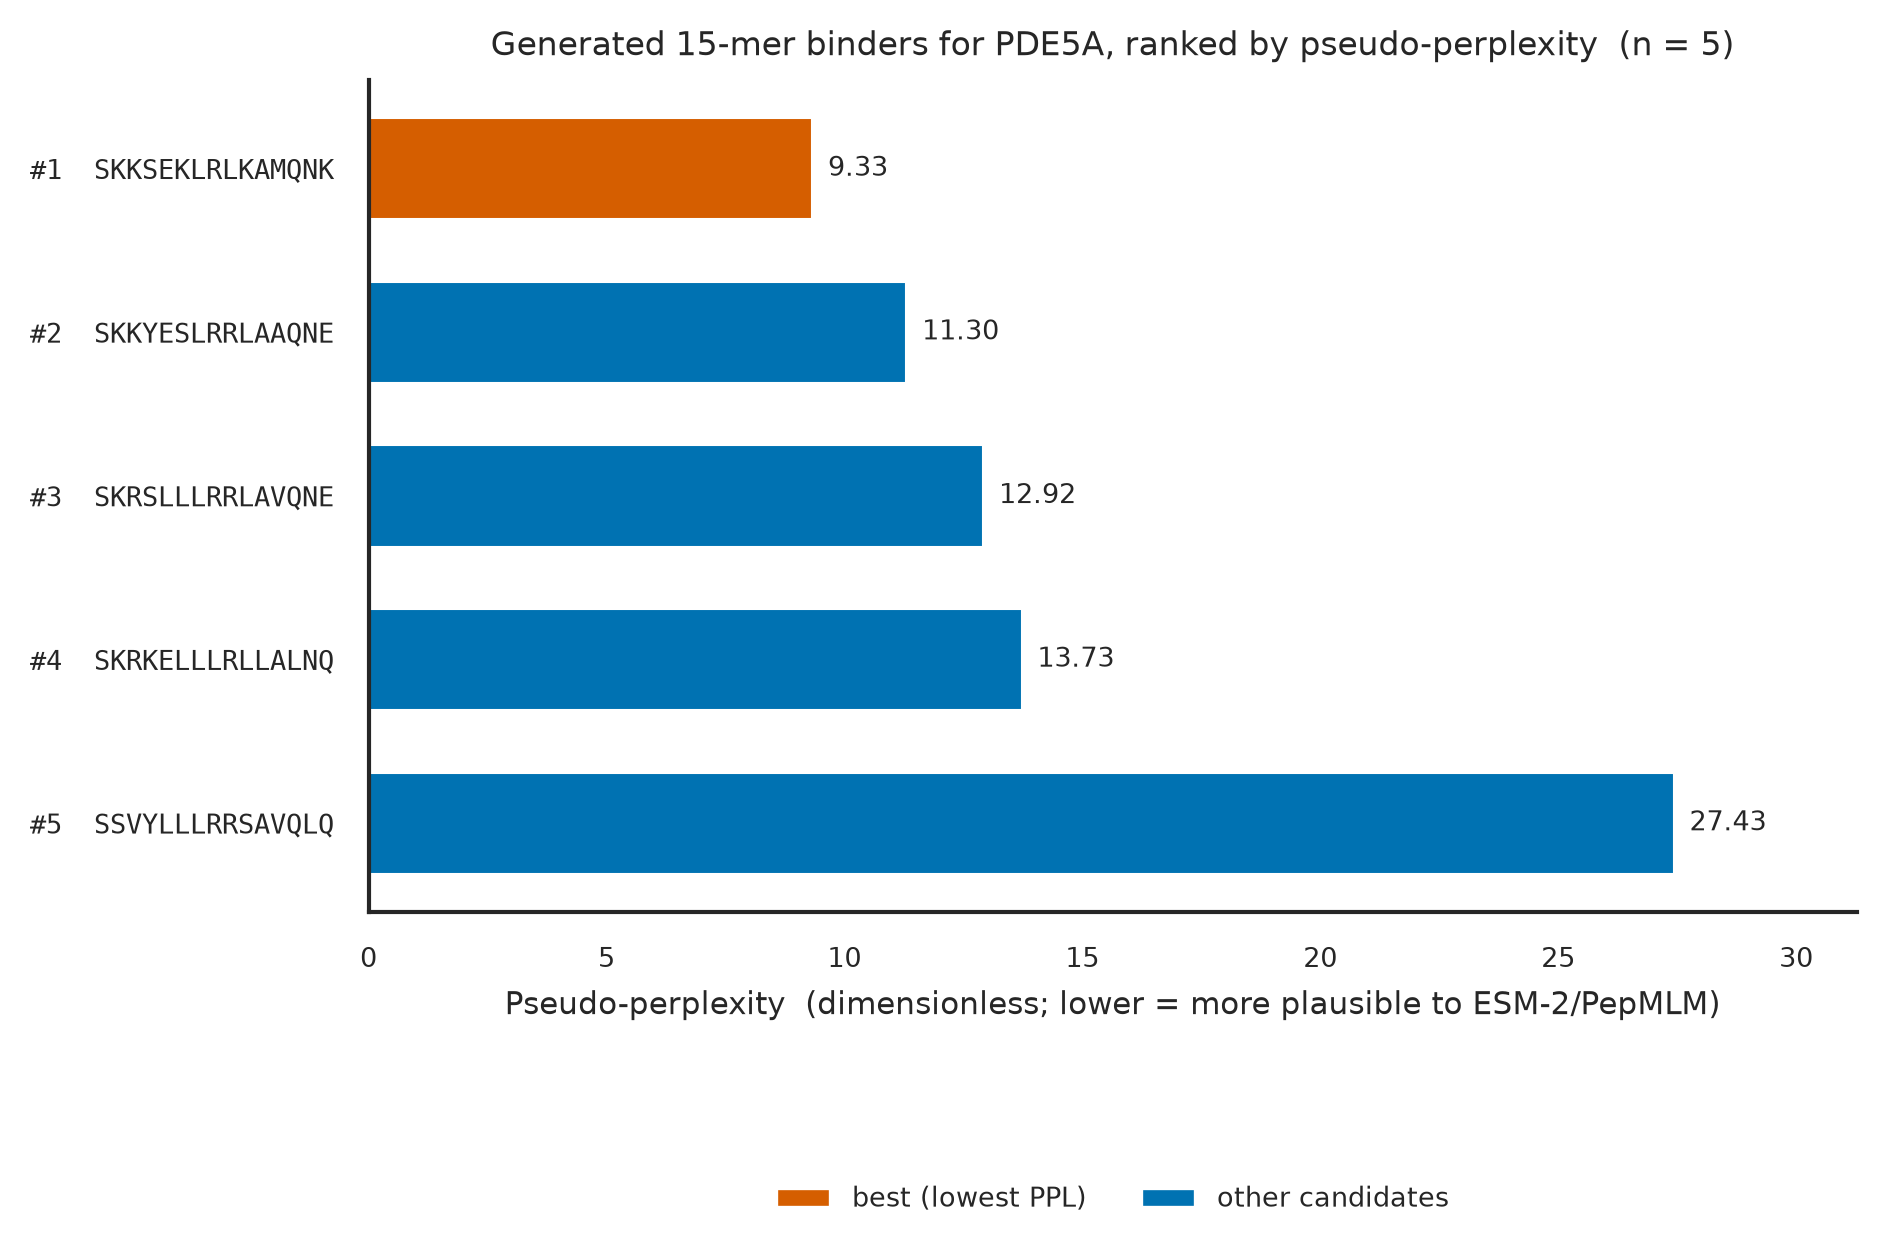

best candidate : SKKSEKLRLKAMQNK | PPL = 9.33
PPL spread     : 9.33 - 27.43 (2.9x)


In [8]:
# === Figure 2. pseudo-perplexity ranking of the generated binders ===
rank_df = results_df.sort_values("Pseudo Perplexity").reset_index(drop=True)
n = len(rank_df)
ypos = np.arange(n)[::-1]
colors = [OK["vermillion"] if i == 0 else OK["blue"] for i in range(n)]

fig, ax = plt.subplots(figsize=(6.4, 0.42 * n + 1.5))
ax.barh(ypos, rank_df["Pseudo Perplexity"], color=colors, height=0.62,
        edgecolor="white", lw=0.5)

for y, v in zip(ypos, rank_df["Pseudo Perplexity"]):
    ax.text(v + rank_df["Pseudo Perplexity"].max() * 0.012, y, f"{v:.2f}",
            va="center", ha="left", fontsize=6.5)

ax.set_yticks(ypos)
ax.set_yticklabels([f"#{i+1}  {s}" for i, s in enumerate(rank_df["Binder"])],
                   fontfamily="monospace", fontsize=6.5)
ax.set_xlim(0, rank_df["Pseudo Perplexity"].max() * 1.14)
ax.set_xlabel("Pseudo-perplexity  (dimensionless; lower = more plausible to ESM-2/PepMLM)")
ax.set_title(f"Generated 15-mer binders for PDE5A, ranked by pseudo-perplexity  (n = {n})")
ax.legend(handles=[Patch(facecolor=OK["vermillion"], label="best (lowest PPL)"),
                   Patch(facecolor=OK["blue"], label="other candidates")],
          loc="upper center", bbox_to_anchor=(0.5, -0.30), ncol=2, frameon=False)
plt.show()

print("best candidate :", rank_df.loc[0, "Binder"],
      "| PPL = %.2f" % rank_df.loc[0, "Pseudo Perplexity"])
print("PPL spread     : %.2f - %.2f (%.1fx)" % (
    rank_df["Pseudo Perplexity"].min(), rank_df["Pseudo Perplexity"].max(),
    rank_df["Pseudo Perplexity"].max() / rank_df["Pseudo Perplexity"].min()))


### 4-4. 그림 3. 생성 펩타이드의 아미노산 조성 vs 표적 단백질 배경 조성

모델이 어떤 아미노산을 **편애**하는지 봅니다. 비교 기준(배경)은 임의의 외부 통계가 아니라
**이 노트북의 입력인 PDE5A(875 aa) 자신의 조성**입니다.

- **위 패널**: 생성 펩타이드 집합(파랑) vs PDE5A 배경(회색)의 아미노산 빈도(%).
- **아래 패널**: log2(생성/배경) 농축도. 오른쪽(양수)일수록 모델이 그 아미노산을 배경보다 더 많이 넣었다는 뜻입니다.
- 통계를 위해 **동일한 마스크 로짓 + 동일한 top-k=3 샘플링을 200회** 반복한 집합을 씁니다.
  Fig 1 에서 이미 계산한 로짓을 재사용하므로 추가 forward pass 는 없고, 표의 후보 5개와 정확히 같은 확률분포에서 나온 표본입니다.

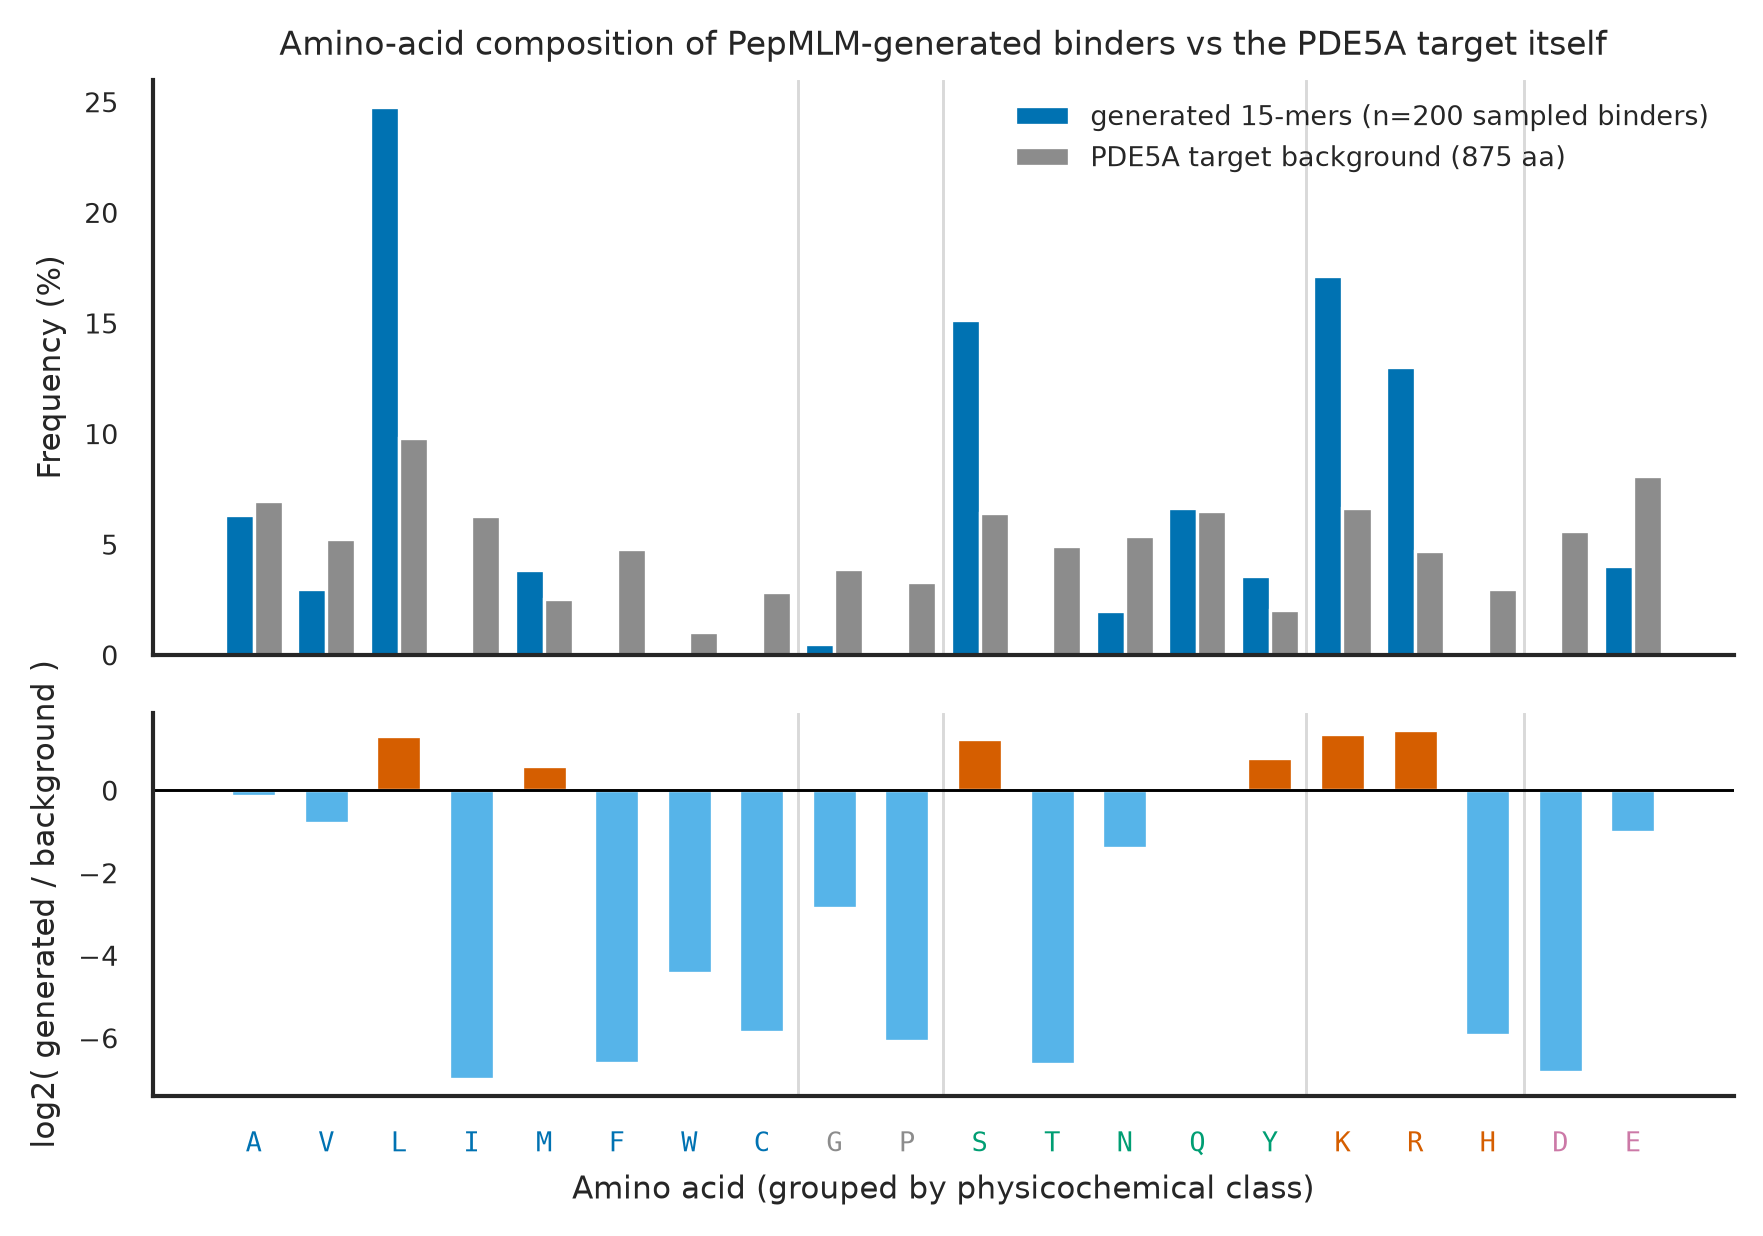

most enriched vs PDE5A background : R, K, L, S, Y
most depleted vs PDE5A background : I, D, T, F, P


In [9]:
# === Figure 3. amino-acid composition: generated binders vs PDE5A background ===
# Fig 1 에서 이미 구한 logits_at_masks 를 재사용 —
# generate_peptide_for_single_sequence() 의 샘플링 단계(topk -> softmax -> Categorical)와 동일합니다.
N_ENSEMBLE = 200
torch.manual_seed(0)

topk_logits, topk_idx = logits_at_masks.topk(TOP_K, dim=-1)        # (15, 3)
topk_probs = torch.softmax(topk_logits, dim=-1)
draws = torch.distributions.Categorical(topk_probs).sample((N_ENSEMBLE,))   # (N, 15)
sampled_ids = topk_idx.unsqueeze(0).expand(N_ENSEMBLE, -1, -1) \
                      .gather(-1, draws.unsqueeze(-1)).squeeze(-1)
ensemble = [tokenizer.decode(t, skip_special_tokens=True).replace(" ", "")
            for t in sampled_ids.cpu()]
ensemble = [s for s in ensemble if len(s) == PEPTIDE_LENGTH and set(s) <= set(AA_ORDER)]

gen_all = "".join(ensemble)
gen_freq = np.array([gen_all.count(a) for a in AA_ORDER], float)
gen_freq = 100 * gen_freq / gen_freq.sum()
bg_freq = np.array([protein_seq.count(a) for a in AA_ORDER], float)
bg_freq = 100 * bg_freq / bg_freq.sum()
enrich = np.log2((gen_freq + 0.05) / (bg_freq + 0.05))

x = np.arange(20)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6.8, 4.4), sharex=True,
                               gridspec_kw={"height_ratios": [1.5, 1.0], "hspace": 0.12})

ax1.bar(x - 0.20, gen_freq, width=0.40, color=OK["blue"],
        label=f"generated 15-mers (n={len(ensemble)} sampled binders)")
ax1.bar(x + 0.20, bg_freq, width=0.40, color=OK["grey"],
        label="PDE5A target background (875 aa)")
ax1.set_ylabel("Frequency (%)")
ax1.legend(frameon=False, loc="upper right")
ax1.set_title("Amino-acid composition of PepMLM-generated binders vs the PDE5A target itself")

ax2.bar(x, enrich, width=0.62,
        color=[OK["vermillion"] if v > 0 else OK["skyblue"] for v in enrich])
ax2.axhline(0, color="black", lw=0.7)
ax2.set_ylabel("log2( generated / background )")
ax2.set_xlabel("Amino acid (grouped by physicochemical class)")
ax2.set_xticks(x)
ax2.set_xticklabels(AA_ORDER, fontfamily="monospace")
for t, a in zip(ax2.get_xticklabels(), AA_ORDER):
    t.set_color(AA_COLOR[a])

# 그룹 경계 표시
b = 0
for name, aas, col in AA_GROUPS[:-1]:
    b += len(aas)
    for a in (ax1, ax2):
        a.axvline(b - 0.5, color="0.85", lw=0.7, zorder=0)

plt.show()
top_up = [AA_ORDER[i] for i in np.argsort(enrich)[::-1][:5]]
top_dn = [AA_ORDER[i] for i in np.argsort(enrich)[:5]]
print("most enriched vs PDE5A background :", ", ".join(top_up))
print("most depleted vs PDE5A background :", ", ".join(top_dn))


### 4-5. 그림 4. 서열 로고 (sequence logo)

Fig 3 이 "전체 조성"이라면, 로고는 **자리마다** 어떤 아미노산이 선호되는지를 보여줍니다.

- **읽는 법**: 글자 높이 = 그 아미노산의 정보량 기여(bits). 기둥이 **높을수록 그 자리가 보존적**(모델이 특정 잔기를 고집),
  낮고 뭉개질수록 자유로운 자리입니다. 최대 높이는 log2(20) = 4.32 bits.
- Fig 3 과 같은 200개 샘플 집합을 씁니다. `logomaker` 가 있으면 진짜 로고로, 없으면 **누적 막대**로 자동 대체(fallback)됩니다.

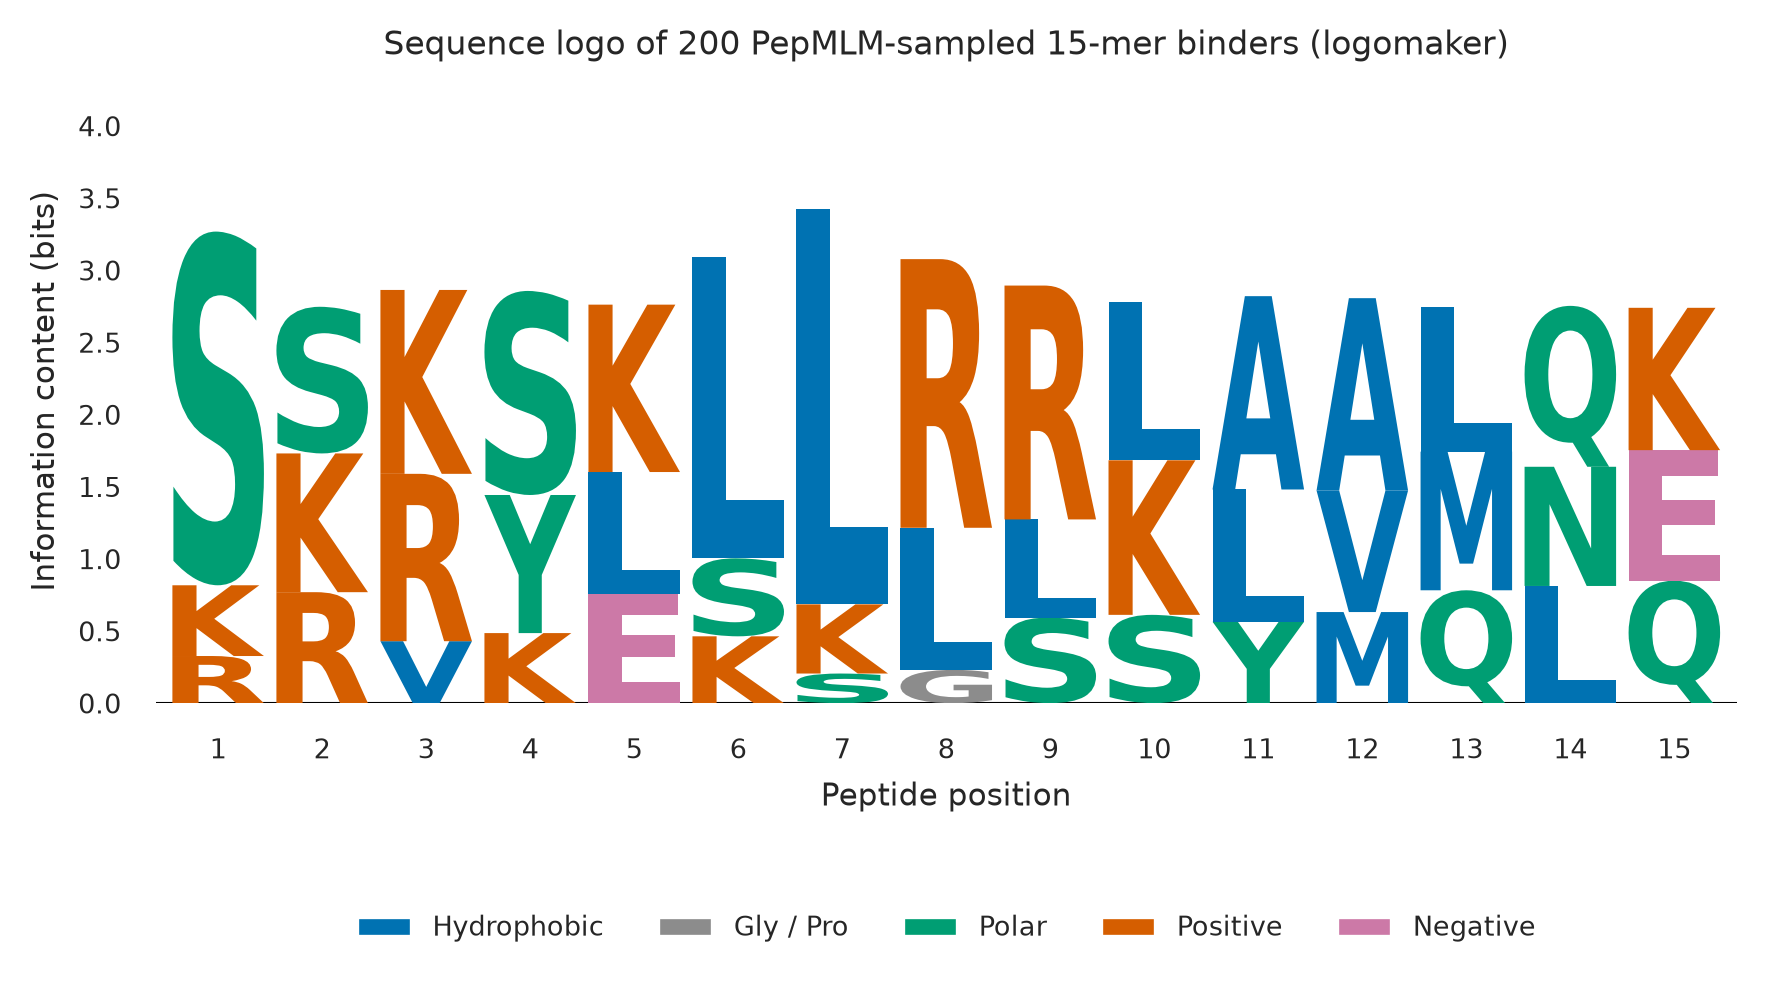

most conserved positions (bits):  pos7=3.42, pos1=3.27, pos6=3.09, pos8=3.08
most variable positions  (bits):  pos15=2.74, pos13=2.74, pos2=2.75, pos14=2.75


In [10]:
# === Figure 4. sequence logo of the sampled binders ===
# logomaker 는 0절 ensure(REQUIRED) 가 설치를 보장한다. 그래도 없으면 누적 막대로 대체한다.
try:
    import logomaker
except ImportError:
    logomaker = None
    print("[fallback] logomaker unavailable -> stacked-bar logo")

# position frequency matrix -> information content
pfm = np.zeros((PEPTIDE_LENGTH, 20))
for s in ensemble:
    for j, ch in enumerate(s):
        pfm[j, AA_INDEX[ch]] += 1
freq = pfm / pfm.sum(axis=1, keepdims=True)
ic = np.log2(20) + (freq * np.log2(np.clip(freq, 1e-12, None))).sum(axis=1)   # bits
heights = freq * ic[:, None]

drawn = False
if logomaker is not None:
    try:
        import pandas as _pd
        logo_df = _pd.DataFrame(heights, columns=AA_ORDER,
                                index=np.arange(1, PEPTIDE_LENGTH + 1))
        fig, ax = plt.subplots(figsize=(6.8, 2.7))
        logomaker.Logo(logo_df, ax=ax, color_scheme=AA_COLOR, width=0.88,
                       stack_order="big_on_top", show_spines=False)
        drawn = True
    except Exception as exc:                      # pragma: no cover
        print("[fallback] logomaker failed ->", type(exc).__name__, exc)
        plt.close(fig)

if not drawn:                                     # matplotlib 누적 막대 폴백
    fig, ax = plt.subplots(figsize=(6.8, 2.7))
    for j in range(PEPTIDE_LENGTH):
        bottom = 0.0
        for i in np.argsort(heights[j]):          # 작은 것부터 아래로
            h = heights[j, i]
            if h <= 1e-3:
                continue
            ax.bar(j + 1, h, bottom=bottom, width=0.82,
                   color=AA_COLOR[AA_ORDER[i]], edgecolor="white", lw=0.3)
            if h > 0.18:
                ax.text(j + 1, bottom + h / 2, AA_ORDER[i], ha="center", va="center",
                        fontsize=5.6, fontweight="bold", color="white",
                        fontfamily="monospace")
            bottom += h

ax.set_xticks(range(1, PEPTIDE_LENGTH + 1))
ax.set_xlim(0.4, PEPTIDE_LENGTH + 0.6)
ax.set_ylim(0, np.log2(20))
ax.set_xlabel("Peptide position")
ax.set_ylabel("Information content (bits)")
ax.set_title(f"Sequence logo of {len(ensemble)} PepMLM-sampled 15-mer binders "
             f"({'logomaker' if drawn else 'matplotlib stacked-bar fallback'})")
ax.legend(handles=[Patch(facecolor=c, label=nm) for nm, _, c in AA_GROUPS],
          ncol=5, frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.30))
plt.show()

print("most conserved positions (bits): ",
      ", ".join(f"pos{j+1}={ic[j]:.2f}" for j in np.argsort(ic)[::-1][:4]))
print("most variable positions  (bits): ",
      ", ".join(f"pos{j+1}={ic[j]:.2f}" for j in np.argsort(ic)[:4]))


## 5. EvoProtGrad 로 in silico 방향진화

EvoProtGrad는 gradient 기반 discrete MCMC로 서열을 탐색하는 in silico 방향진화(directed evolution)
라이브러리입니다. 여기서는 작은 ESM-2(`facebook/esm2_t6_8M_UR50D`)를 "전문가(expert)" 모델로 쓰고,
표적 단백질과 링커 구간은 `preserved_regions` 로 고정한 채 **뒤쪽 15-mer 펩타이드만** 변이시킵니다.

> `scoring_strategy='mutant_marginal'` 을 씁니다. EvoProtGrad의 기본값인 `pseudolikelihood_ratio`
> 는 최신 transformers에서 텐서 차원 불일치로 실패합니다.

In [11]:
# evo_prot_grad 설치
#
# 두 가지 주의사항이 있습니다.
# 1) !pip install evo_prot_grad>=0.1.0 처럼 쓰면 셸이 ">"를 리다이렉션으로 해석해
#    버전 조건이 무시되고 "=0.1.0" 이라는 파일이 생깁니다. 반드시 따옴표로 묶습니다.
# 2) evo_prot_grad 0.2는 transformers==4.38.0 을 정확히 고정하고 있어서 그대로 설치하면
#    transformers가 2024년 버전으로 강제 다운그레이드되고 앞 단계가 깨집니다.
#    --no-deps 로 설치해 현재 transformers를 유지합니다.
#    (--no-deps 로 설치해도 evo_prot_grad 0.2 는 최신 transformers에서 정상 동작합니다.)
!pip install -q --no-deps "evo_prot_grad>=0.2"

import torch
import evo_prot_grad
from transformers import AutoTokenizer, EsmForMaskedLM

print("evo_prot_grad import OK")

evo_prot_grad import OK


In [12]:
def run_evo_prot_grad_on_paired_sequence(paired_protein_sequence):
    """표적:펩타이드 쌍 서열을 받아 15-mer 구간만 EvoProtGrad 로 진화시키고 추적 기록을 돌려준다."""
    # Replace ':' with a string of 20 'G' amino acids
    separator = 'G' * 20
    sequence_with_separator = paired_protein_sequence.replace(':', separator)

    # Determine the start and end indices of the first protein and the separator
    separator_start_index = sequence_with_separator.find(separator)
    first_protein_end_index = separator_start_index
    separator_end_index = separator_start_index + len(separator)

    # Format the sequence into FASTA format
    fasta_format_sequence = f">Paired_Protein_Sequence\n{sequence_with_separator}"

    # Save the sequence to a temporary file
    temp_fasta_path = "temp_paired_sequence.fasta"
    with open(temp_fasta_path, "w") as file:
        file.write(fasta_format_sequence)

    # Use a smaller ESM-2 model to reduce memory usage
    esm2_expert = evo_prot_grad.get_expert(
        'esm',
        model=EsmForMaskedLM.from_pretrained("facebook/esm2_t6_8M_UR50D"),  # Use a smaller ESM-2 model
        tokenizer=AutoTokenizer.from_pretrained("facebook/esm2_t6_8M_UR50D"),
        # pseudolikelihood_ratio는 최신 transformers에서 텐서 차원 불일치로 실패합니다.
        # mutant_marginal은 EvoProtGrad 논문에서 권장하는 전략이며 정상 동작합니다.
        scoring_strategy='mutant_marginal',
        temperature=0.95,
        device=DEVICE  # 0절에서 정한 연산 장치
    )

    # Initialize wildtype sequence for the expert with the correct format
    wildtype_sequence = sequence_with_separator.replace(" ", "")  # Make sure the input sequence has no spaces
    esm2_expert.init_wildtype(wildtype_sequence)

    # Initialize Directed Evolution with the preserved first protein and separator region
    directed_evolution = evo_prot_grad.DirectedEvolution(
        wt_fasta=temp_fasta_path,
        output='best',
        experts=[esm2_expert],
        parallel_chains=1,  # Reduce parallel chains to save memory
        n_steps=50,
        max_mutations=15,
        verbose=True,
        preserved_regions=[(0, first_protein_end_index), (separator_start_index, separator_end_index)]
    )

    # Run the evolution process
    variants, scores = directed_evolution()

    # Process the results and split them into Protein 1 and Protein 2
    for variant, score in zip(variants, scores):
        # Remove spaces from the sequence
        evolved_sequence_no_spaces = variant.replace(" ", "")

        # Split the sequence at the separator
        protein_1, protein_2 = evolved_sequence_no_spaces.split(separator)

        print(f"Protein: {protein_1}, Evolved Peptide: {protein_2}, Score: {score}")

    # --- 시각화(Fig 5/Fig 6)를 위한 추적 기록 반환 ---
    # 위의 출력/동작은 그대로이고, DirectedEvolution 이 내부에 이미 쌓아둔
    # PoE_history(스텝별 점수)와 chains_oh_history(스텝별 서열)를 꺼내서 돌려줍니다.
    # (새로 계산하는 값이 아니라 이미 계산된 값을 그대로 반환합니다.)
    best_variant = variants[0].replace(" ", "")
    return {
        "wildtype_sequence": wildtype_sequence,
        "best_variant": best_variant,
        "wt_peptide": wildtype_sequence.split(separator)[1],
        "best_peptide": best_variant.split(separator)[1],
        "best_score": float(np.asarray(scores).reshape(-1)[0]),
        "score_history": [p.detach().cpu().numpy().reshape(-1).tolist()
                          for p in directed_evolution.PoE_history],
        "variant_history": [directed_evolution.canonical_chain_tokenizer.decode(h)
                            for h in directed_evolution.chains_oh_history],
        "separator": separator,
        "peptide_start": separator_end_index,
        "preserved_regions": [(0, first_protein_end_index),
                              (separator_start_index, separator_end_index)],
    }

In [13]:
# 전문가 모델로는 작은 facebook/esm2_t6_8M_UR50D(8M)를 쓰므로 메모리 부담이 적습니다.
# n_steps=50, max_mutations=15, parallel_chains=1 기준으로 CPU에서도 1분 내외에 끝납니다.
# preserved_regions 로 표적(PDE5A)과 GGG...G 링커는 고정하고, 뒤쪽 15-mer 펩타이드만 진화시킵니다.
# Example usage
paired_protein_sequence = "MERAGPSFGQQRQQQQPQQQKQQQRDQDSVEAWLDDHWDFTFSYFVRKATREMVNAWFAERVHTIPVCKEGIRGHTESCSCPLQQSPRADNSAPGTPTRKISASEFDRPLRPIVVKDSEGTVSFLSDSEKKEQMPLTPPRFDHDEGDQCSRLLELVKDISSHLDVTALCHKIFLHIHGLISADRYSLFLVCEDSSNDKFLISRLFDVAEGSTLEEVSNNCIRLEWNKGIVGHVAALGEPLNIKDAYEDPRFNAEVDQITGYKTQSILCMPIKNHREEVVGVAQAINKKSGNGGTFTEKDEKDFAAYLAFCGIVLHNAQLYETSLLENKRNQVLLDLASLIFEEQQSLEVILKKIAATIISFMQVQKCTIFIVDEDCSDSFSSVFHMECEELEKSSDTLTREHDANKINYMYAQYVKNTMEPLNIPDVSKDKRFPWTTENTGNVNQQCIRSLLCTPIKNGKKNKVIGVCQLVNKMEENTGKVKPFNRNDEQFLEAFVIFCGLGIQNTQMYEAVERAMAKQMVTLEVLSYHASAAEEETRELQSLAAAVVPSAQTLKITDFSFSDFELSDLETALCTIRMFTDLNLVQNFQMKHEVLCRWILSVKKNYRKNVAYHNWRHAFNTAQCMFAALKAGKIQNKLTDLEILALLIAALSHDLDHRGVNNSYIQRSEHPLAQLYCHSIMEHHHFDQCLMILNSPGNQILSGLSIEEYKTTLKIIKQAILATDLALYIKRRGEFFELIRKNQFNLEDPHQKELFLAMLMTACDLSAITKPWPIQQRIAELVATEFFDQGDRERKELNIEPTDLMNREKKNKIPSMQVGFIDAICLQLYEALTHVSEDCFPLLDGCRKNRQKWQALAEQQEKMLINGESGQAKRN:FDEDDPLAPRLLEEE"  # 표적 PDE5A (UniProt O76074) : 초기 15-mer 펩타이드 바인더
evo_result = run_evo_prot_grad_on_paired_sequence(paired_protein_sequence)

Loading weights:   0%|          | 0/107 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 107/107 [00:00<00:00, 10959.74it/s]

>Wildtype sequence: M E R A G P S F G Q Q R Q Q Q Q P Q Q Q K Q Q Q R D Q D S V E A W L D D H W D F T F S Y F V R K A T R E M V N A W F A E R V H T I P V C K E G I R G H T E S C S C P L Q Q S P R A D N S A P G T P T R K I S A S E F D R P L R P I V V K D S E G T V S F L S D S E K K E Q M P L T P P R F D H D E G D Q C S R L L E L V K D I S S H L D V T A L C H K I F L H I H G L I S A D R Y S L F L V C E D S S N D K F L I S R L F D V A E G S T L E E V S N N C I R L E W N K G I V G H V A A L G E P L N I K D A Y E D P R F N A E V D Q I T G Y K T Q S I L C M P I K N H R E E V V G V A Q A I N K K S G N G G T F T E K D E K D F A A Y L A F C G I V L H N A Q L Y E T S L L E N K R N Q V L L D L A S L I F E E Q Q S L E V I L K K I A A T I I S F M Q V Q K C T I F I V D E D C S D S F S S V F H M E C E E L E K S S D T L T R E H D A N K I N Y M Y A Q Y V K N T M E P L N I P D V S K D K R F P W T T E N T G N V N Q Q C I R S L L C T P I K N G K K N K V I G V C Q L V N K M E E N T G K V K P F N R N D E Q 

step 0 acceptance rate: 5.2060
>chain 0, Product of Experts score: 4.9915
M E R A G P S F G Q Q R Q Q Q Q P Q Q Q K Q Q Q R D Q D S V E A W L D D H W D F T F S Y F V R K A T R E M V N A W F A E R V H T I P V C K E G I R G H T E S C S C P L Q Q S P R A D N S A P G T P T R K I S A S E F D R P L R P I V V K D S E G T V S F L S D S E K K E Q M P L T P P R F D H D E G D Q C S R L L E L V K D I S S H L D V T A L C H K I F L H I H G L I S A D R Y S L F L V C E D S S N D K F L I S R L F D V A E G S T L E E V S N N C I R L E W N K G I V G H V A A L G E P L N I K D A Y E D P R F N A E V D Q I T G Y K T Q S I L C M P I K N H R E E V V G V A Q A I N K K S G N G G T F T E K D E K D F A A Y L A F C G I V L H N A Q L Y E T S L L E N K R N Q V L L D L A S L I F E E Q Q S L E V I L K K I A A T I I S F M Q V Q K C T I F I V D E D C S D S F S S V F H M E C E E L E K S S D T L T R E H D A N K I N Y M Y A Q Y V K N T M E P L N I P D V S K D K R F P W T T E N T G N V N Q Q C I R S L L C T P I K N G K K N K 

step 1 acceptance rate: 0.0003
>chain 0, Product of Experts score: 4.9915
M E R A G P S F G Q Q R Q Q Q Q P Q Q Q K Q Q Q R D Q D S V E A W L D D H W D F T F S Y F V R K A T R E M V N A W F A E R V H T I P V C K E G I R G H T E S C S C P L Q Q S P R A D N S A P G T P T R K I S A S E F D R P L R P I V V K D S E G T V S F L S D S E K K E Q M P L T P P R F D H D E G D Q C S R L L E L V K D I S S H L D V T A L C H K I F L H I H G L I S A D R Y S L F L V C E D S S N D K F L I S R L F D V A E G S T L E E V S N N C I R L E W N K G I V G H V A A L G E P L N I K D A Y E D P R F N A E V D Q I T G Y K T Q S I L C M P I K N H R E E V V G V A Q A I N K K S G N G G T F T E K D E K D F A A Y L A F C G I V L H N A Q L Y E T S L L E N K R N Q V L L D L A S L I F E E Q Q S L E V I L K K I A A T I I S F M Q V Q K C T I F I V D E D C S D S F S S V F H M E C E E L E K S S D T L T R E H D A N K I N Y M Y A Q Y V K N T M E P L N I P D V S K D K R F P W T T E N T G N V N Q Q C I R S L L C T P I K N G K K N K 

...

step 45 acceptance rate: 0.0046
>chain 0, Product of Experts score: 100.8715
M E R A G P S F G Q Q R Q Q Q Q P Q Q Q K Q Q Q R D Q D S V E A W L D D H W D F T F S Y F V R K A T R E M V N A W F A E R V H T I P V C K E G I R G H T E S C S C P L Q Q S P R A D N S A P G T P T R K I S A S E F D R P L R P I V V K D S E G T V S F L S D S E K K E Q M P L T P P R F D H D E G D Q C S R L L E L V K D I S S H L D V T A L C H K I F L H I H G L I S A D R Y S L F L V C E D S S N D K F L I S R L F D V A E G S T L E E V S N N C I R L E W N K G I V G H V A A L G E P L N I K D A Y E D P R F N A E V D Q I T G Y K T Q S I L C M P I K N H R E E V V G V A Q A I N K K S G N G G T F T E K D E K D F A A Y L A F C G I V L H N A Q L Y E T S L L E N K R N Q V L L D L A S L I F E E Q Q S L E V I L K K I A A T I I S F M Q V Q K C T I F I V D E D C S D S F S S V F H M E C E E L E K S S D T L T R E H D A N K I N Y M Y A Q Y V K N T M E P L N I P D V S K D K R F P W T T E N T G N V N Q Q C I R S L L C T P I K N G K K N

step 46 acceptance rate: 0.0000
>chain 0, Product of Experts score: 100.8715
M E R A G P S F G Q Q R Q Q Q Q P Q Q Q K Q Q Q R D Q D S V E A W L D D H W D F T F S Y F V R K A T R E M V N A W F A E R V H T I P V C K E G I R G H T E S C S C P L Q Q S P R A D N S A P G T P T R K I S A S E F D R P L R P I V V K D S E G T V S F L S D S E K K E Q M P L T P P R F D H D E G D Q C S R L L E L V K D I S S H L D V T A L C H K I F L H I H G L I S A D R Y S L F L V C E D S S N D K F L I S R L F D V A E G S T L E E V S N N C I R L E W N K G I V G H V A A L G E P L N I K D A Y E D P R F N A E V D Q I T G Y K T Q S I L C M P I K N H R E E V V G V A Q A I N K K S G N G G T F T E K D E K D F A A Y L A F C G I V L H N A Q L Y E T S L L E N K R N Q V L L D L A S L I F E E Q Q S L E V I L K K I A A T I I S F M Q V Q K C T I F I V D E D C S D S F S S V F H M E C E E L E K S S D T L T R E H D A N K I N Y M Y A Q Y V K N T M E P L N I P D V S K D K R F P W T T E N T G N V N Q Q C I R S L L C T P I K N G K K N

step 47 acceptance rate: 0.0000
>chain 0, Product of Experts score: 100.8715
M E R A G P S F G Q Q R Q Q Q Q P Q Q Q K Q Q Q R D Q D S V E A W L D D H W D F T F S Y F V R K A T R E M V N A W F A E R V H T I P V C K E G I R G H T E S C S C P L Q Q S P R A D N S A P G T P T R K I S A S E F D R P L R P I V V K D S E G T V S F L S D S E K K E Q M P L T P P R F D H D E G D Q C S R L L E L V K D I S S H L D V T A L C H K I F L H I H G L I S A D R Y S L F L V C E D S S N D K F L I S R L F D V A E G S T L E E V S N N C I R L E W N K G I V G H V A A L G E P L N I K D A Y E D P R F N A E V D Q I T G Y K T Q S I L C M P I K N H R E E V V G V A Q A I N K K S G N G G T F T E K D E K D F A A Y L A F C G I V L H N A Q L Y E T S L L E N K R N Q V L L D L A S L I F E E Q Q S L E V I L K K I A A T I I S F M Q V Q K C T I F I V D E D C S D S F S S V F H M E C E E L E K S S D T L T R E H D A N K I N Y M Y A Q Y V K N T M E P L N I P D V S K D K R F P W T T E N T G N V N Q Q C I R S L L C T P I K N G K K N

step 48 acceptance rate: 0.0000
>chain 0, Product of Experts score: 100.8715
M E R A G P S F G Q Q R Q Q Q Q P Q Q Q K Q Q Q R D Q D S V E A W L D D H W D F T F S Y F V R K A T R E M V N A W F A E R V H T I P V C K E G I R G H T E S C S C P L Q Q S P R A D N S A P G T P T R K I S A S E F D R P L R P I V V K D S E G T V S F L S D S E K K E Q M P L T P P R F D H D E G D Q C S R L L E L V K D I S S H L D V T A L C H K I F L H I H G L I S A D R Y S L F L V C E D S S N D K F L I S R L F D V A E G S T L E E V S N N C I R L E W N K G I V G H V A A L G E P L N I K D A Y E D P R F N A E V D Q I T G Y K T Q S I L C M P I K N H R E E V V G V A Q A I N K K S G N G G T F T E K D E K D F A A Y L A F C G I V L H N A Q L Y E T S L L E N K R N Q V L L D L A S L I F E E Q Q S L E V I L K K I A A T I I S F M Q V Q K C T I F I V D E D C S D S F S S V F H M E C E E L E K S S D T L T R E H D A N K I N Y M Y A Q Y V K N T M E P L N I P D V S K D K R F P W T T E N T G N V N Q Q C I R S L L C T P I K N G K K N

step 49 acceptance rate: 0.0000
>chain 0, Product of Experts score: 100.8715
M E R A G P S F G Q Q R Q Q Q Q P Q Q Q K Q Q Q R D Q D S V E A W L D D H W D F T F S Y F V R K A T R E M V N A W F A E R V H T I P V C K E G I R G H T E S C S C P L Q Q S P R A D N S A P G T P T R K I S A S E F D R P L R P I V V K D S E G T V S F L S D S E K K E Q M P L T P P R F D H D E G D Q C S R L L E L V K D I S S H L D V T A L C H K I F L H I H G L I S A D R Y S L F L V C E D S S N D K F L I S R L F D V A E G S T L E E V S N N C I R L E W N K G I V G H V A A L G E P L N I K D A Y E D P R F N A E V D Q I T G Y K T Q S I L C M P I K N H R E E V V G V A Q A I N K K S G N G G T F T E K D E K D F A A Y L A F C G I V L H N A Q L Y E T S L L E N K R N Q V L L D L A S L I F E E Q Q S L E V I L K K I A A T I I S F M Q V Q K C T I F I V D E D C S D S F S S V F H M E C E E L E K S S D T L T R E H D A N K I N Y M Y A Q Y V K N T M E P L N I P D V S K D K R F P W T T E N T G N V N Q Q C I R S L L C T P I K N G K K N

### 5-1. 그림 5. EvoProtGrad 방향진화 궤적

바로 위 셀에서 돌린 50 스텝 MCMC 가 **실제로 점수를 올렸는지**를 봅니다.
(점수 = Product-of-Experts score, ESM-2 8M 전문가 모델이 매긴 서열 선호도. 높을수록 좋음.)

- **읽는 법**: 파란 선 = 스텝별 점수, 점선 = 그때까지의 최고점(running max), 별표 = 채택된 최종 best.
- **회색 계단선(오른쪽 축)** = 야생형 대비 누적 변이 개수. `max_mutations=15` 에 닿으면 체인이 야생형으로 리셋되기 때문에
  톱니 모양이 나타날 수 있습니다 — 이것이 EvoProtGrad 의 탐색 방식입니다.

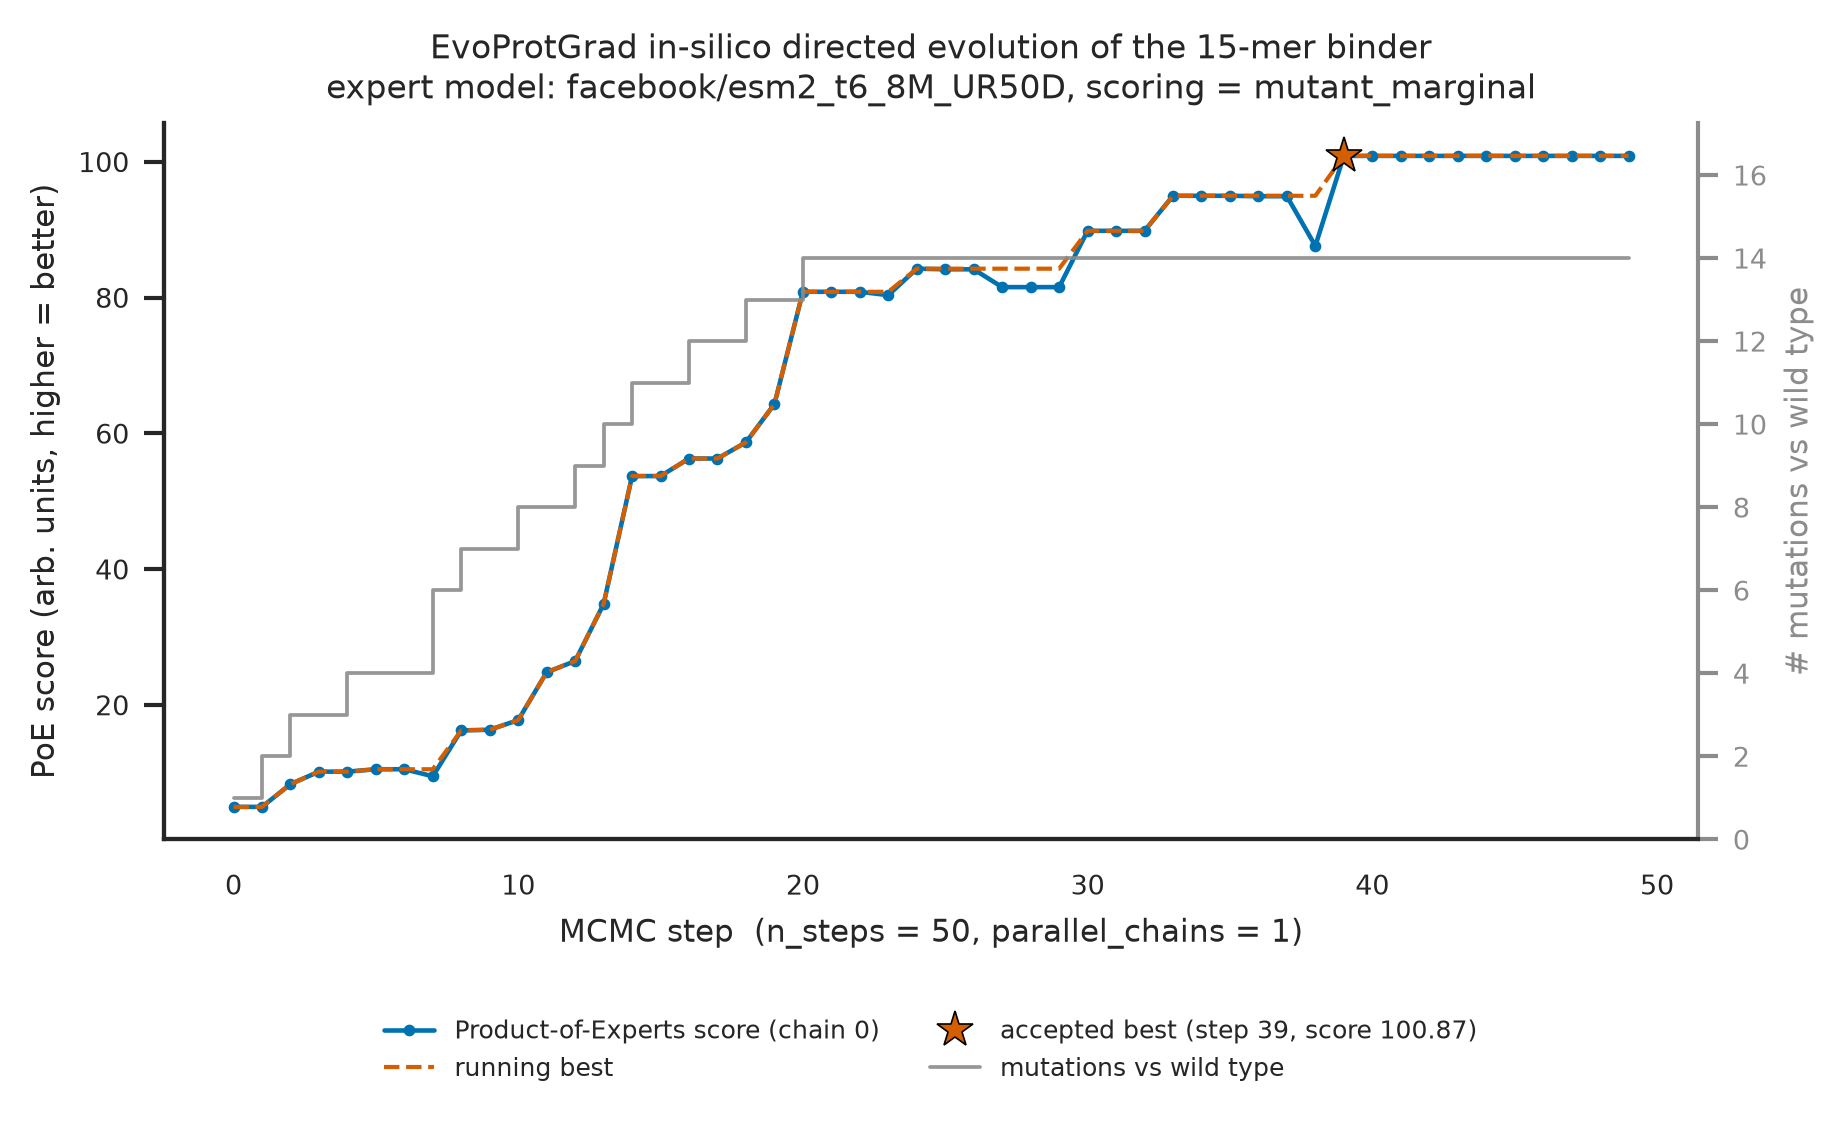

start score : 4.992   |   best score : 100.872   (delta = +95.880)
wild-type peptide : FDEDDPLAPRLLEEE
evolved  peptide  : FGGGGGGGGCGGGCS


In [14]:
# === Figure 5. EvoProtGrad optimisation trajectory ===
# 새로 실행하지 않습니다. 위 셀의 DirectedEvolution 이 이미 쌓아 둔 기록을 그대로 씁니다.
scores_hist = np.array(evo_result["score_history"], dtype=float)[:, 0]   # chain 0
wt_full = evo_result["wildtype_sequence"]
variants_hist = [v[0].replace(" ", "") for v in evo_result["variant_history"]]
n_mut_hist = np.array([sum(a != b for a, b in zip(wt_full, v)) for v in variants_hist])

steps = np.arange(len(scores_hist))
running_max = np.maximum.accumulate(scores_hist)
best_step = int(scores_hist.argmax())

fig, ax = plt.subplots(figsize=(6.6, 3.1))
ax.plot(steps, scores_hist, color=OK["blue"], lw=1.1, marker="o", ms=1.8,
        label="Product-of-Experts score (chain 0)")
ax.plot(steps, running_max, color=OK["vermillion"], lw=1.0, ls="--",
        label="running best")
ax.plot(best_step, scores_hist[best_step], marker="*", ms=9,
        color=OK["vermillion"], mec="black", mew=0.4, ls="none",
        label=f"accepted best (step {best_step}, score {scores_hist[best_step]:.2f})")
ax.set_xlabel("MCMC step  (n_steps = 50, parallel_chains = 1)")
ax.set_ylabel("PoE score (arb. units, higher = better)")
ax.set_title("EvoProtGrad in-silico directed evolution of the 15-mer binder\n"
             "expert model: facebook/esm2_t6_8M_UR50D, scoring = mutant_marginal")

ax2 = ax.twinx()
ax2.step(steps, n_mut_hist, where="post", color=OK["grey"], lw=0.9, alpha=0.9,
         label="mutations vs wild type")
ax2.set_ylabel("# mutations vs wild type", color=OK["grey"])
ax2.tick_params(axis="y", colors=OK["grey"])
ax2.set_ylim(0, max(n_mut_hist.max(), 15) * 1.15)
ax2.spines["right"].set_visible(True)
ax2.spines["right"].set_color(OK["grey"])

h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, frameon=False, loc="upper center",
          bbox_to_anchor=(0.5, -0.22), ncol=2, fontsize=6)
plt.show()

print("start score : %.3f   |   best score : %.3f   (delta = %+.3f)"
      % (scores_hist[0], scores_hist[best_step], scores_hist[best_step] - scores_hist[0]))
print("wild-type peptide :", evo_result["wt_peptide"])
print("evolved  peptide  :", evo_result["best_peptide"])


### 5-2. 그림 6. 변이 위치 맵 — 무엇이 고정되고 무엇이 바뀌었나

`preserved_regions` 가 정말로 표적과 링커를 지켰는지, 그리고 15-mer 안에서 **어느 자리가 바뀌었는지**를 확인합니다.

- **위 패널**: 전체 construct(PDE5A 875 aa + G20 링커 + 15-mer) 도식. 회색 음영 = `preserved_regions`(고정), 주황 = 변이 허용 구간.
  빨간 눈금이 실제로 바뀐 잔기 위치입니다. 눈금이 전부 오른쪽 끝(주황 구간)에만 있어야 정상입니다.
- **아래 패널**: 15-mer 확대. 막대가 선 자리가 변이된 자리이고 `D3G` 식으로 (야생형 → 변이) 를 적었습니다. 아래 두 줄은 서열 정렬입니다.

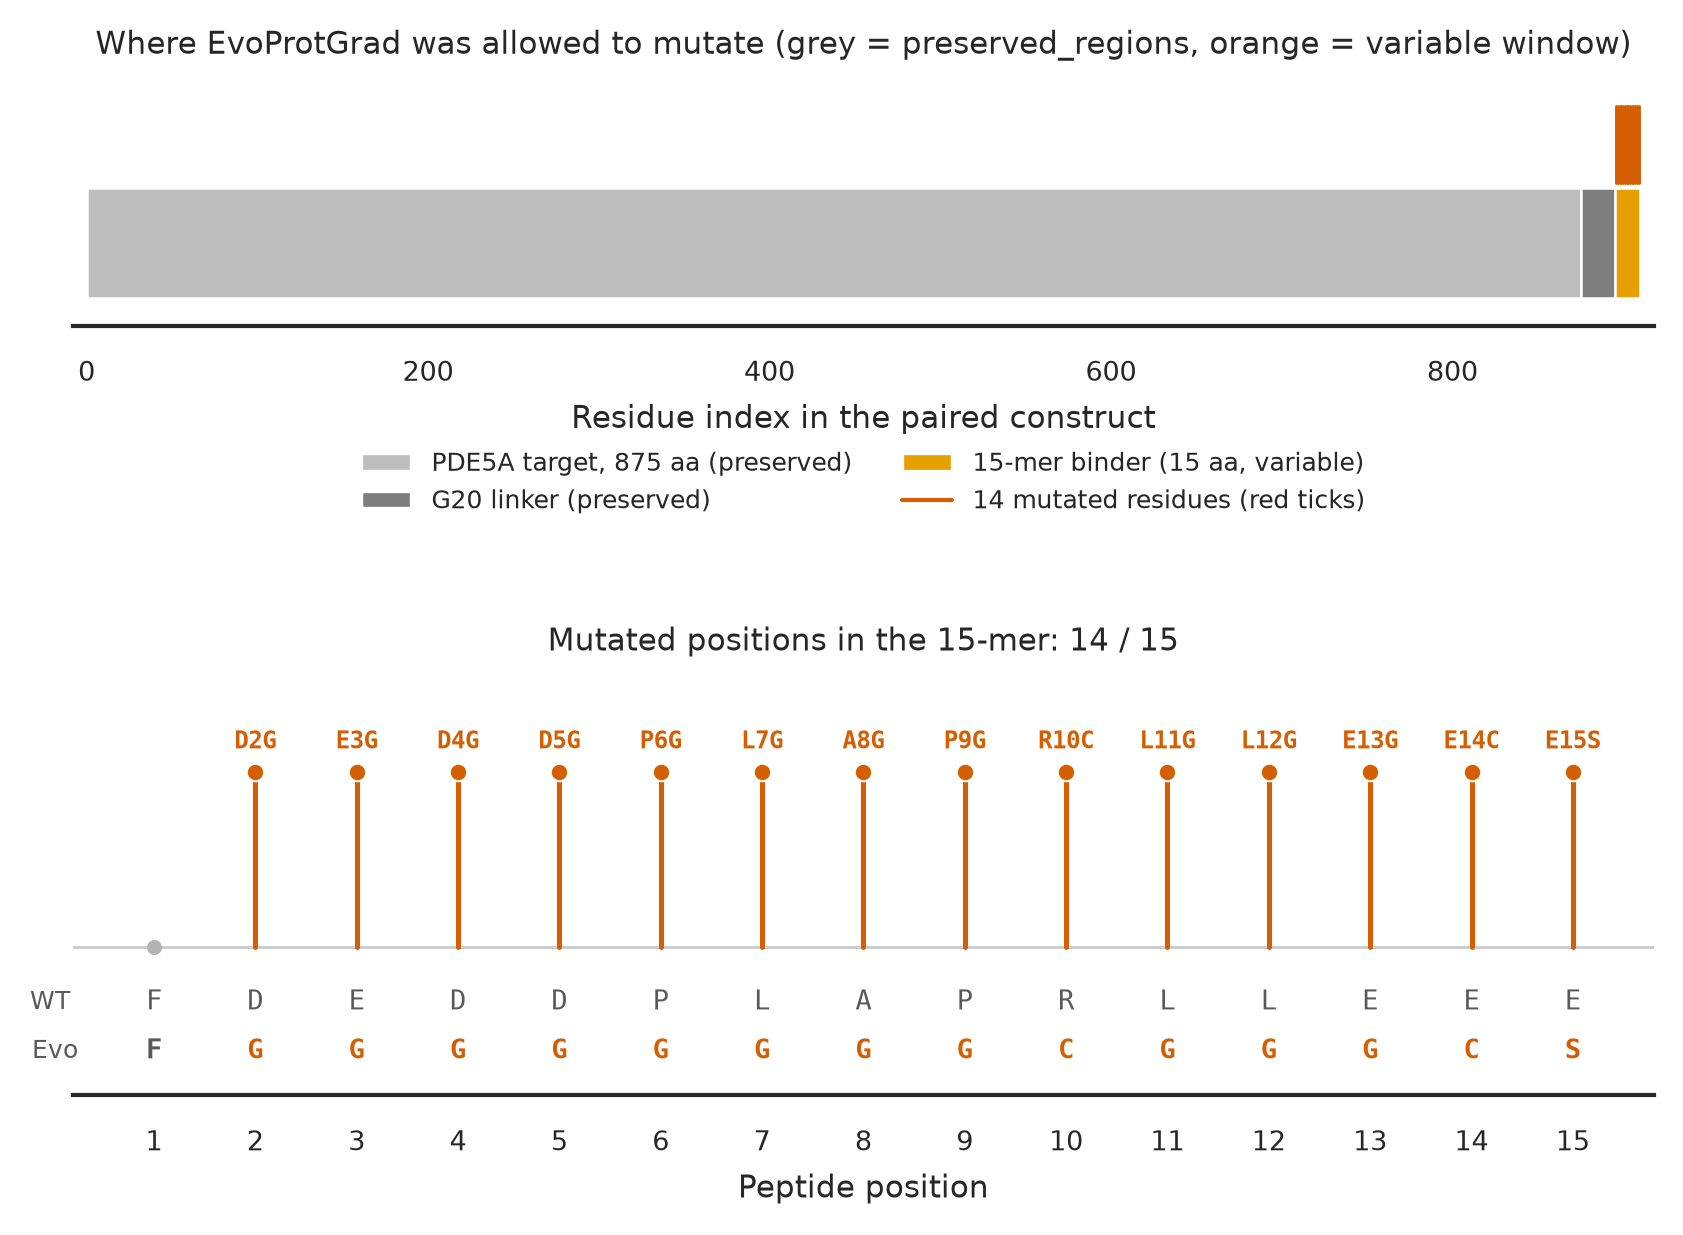

mutations inside the 15-mer  : 14 / 15
mutations in preserved region: 0 (must be 0)
WT  : FDEDDPLAPRLLEEE
Evo : FGGGGGGGGCGGGCS


In [15]:
# === Figure 6. mutation map: preserved regions vs the evolved 15-mer ===
wt_full = evo_result["wildtype_sequence"]
ev_full = evo_result["best_variant"]
pep_start = evo_result["peptide_start"]          # 15-mer 시작 인덱스
L = len(wt_full)
diff_pos = [i for i, (a, b) in enumerate(zip(wt_full, ev_full)) if a != b]

wt_pep, ev_pep = evo_result["wt_peptide"], evo_result["best_peptide"]
mut_j = [j for j in range(len(wt_pep)) if wt_pep[j] != ev_pep[j]]

fig, (axA, axB) = plt.subplots(2, 1, figsize=(6.8, 4.4),
                               gridspec_kw={"height_ratios": [1.0, 1.7], "hspace": 1.05})

# ---- (A) construct-level schematic ------------------------------------------
# 링커(20 aa)와 펩타이드(15 aa)는 875 aa 표적에 비해 아주 짧아서 막대 안에 글씨를 넣을 수
# 없습니다. 구간 설명은 아래 범례로 뺐습니다.
(t0, t1), (l0, l1) = evo_result["preserved_regions"]
for x0, x1, col in [(t0, t1, "#BDBDBD"), (l0, l1, "#7E7E7E"),
                    (pep_start, L, OK["orange"])]:
    axA.add_patch(Rectangle((x0, 0), x1 - x0, 1, facecolor=col, edgecolor="white", lw=0.6))
for p in diff_pos:
    axA.plot([p, p], [1.05, 1.75], color=OK["vermillion"], lw=0.7)
axA.set_xlim(-8, L + 8)
axA.set_ylim(-0.25, 2.0)
axA.set_yticks([])
axA.set_xlabel("Residue index in the paired construct")
axA.spines["left"].set_visible(False)
axA.set_title("Where EvoProtGrad was allowed to mutate "
              "(grey = preserved_regions, orange = variable window)", fontsize=7.5)
from matplotlib.lines import Line2D
axA.legend(handles=[
    Patch(facecolor="#BDBDBD", label=f"PDE5A target, {t1-t0} aa (preserved)"),
    Patch(facecolor="#7E7E7E", label=f"G{l1-l0} linker (preserved)"),
    Patch(facecolor=OK["orange"], label=f"15-mer binder ({L-pep_start} aa, variable)"),
    Line2D([], [], color=OK["vermillion"], lw=1.0,
           label=f"{len(diff_pos)} mutated residues (red ticks)")],
    loc="upper center", bbox_to_anchor=(0.5, -0.42), ncol=2, frameon=False, fontsize=6)

# ---- (B) zoom on the 15-mer --------------------------------------------------
xs = np.arange(1, len(wt_pep) + 1)
axB.axhline(0, color="0.8", lw=0.7)
for j in range(len(wt_pep)):
    if j in mut_j:
        axB.plot([j + 1, j + 1], [0, 1], color=OK["vermillion"], lw=1.2, zorder=2)
        axB.plot(j + 1, 1, "o", ms=4.2, color=OK["vermillion"], mec="white",
                 mew=0.5, zorder=3)
        axB.text(j + 1, 1.10, f"{wt_pep[j]}{j+1}{ev_pep[j]}", ha="center", va="bottom",
                 fontsize=5.8, fontweight="bold", color=OK["vermillion"],
                 fontfamily="monospace")
    else:
        axB.plot(j + 1, 0, "o", ms=2.6, color="0.7", zorder=2)

for j in range(len(wt_pep)):
    axB.text(j + 1, -0.32, wt_pep[j], ha="center", va="center", fontsize=6.4,
             fontfamily="monospace", color="0.35")
    axB.text(j + 1, -0.60, ev_pep[j], ha="center", va="center", fontsize=6.4,
             fontfamily="monospace", fontweight="bold",
             color=OK["vermillion"] if j in mut_j else "0.35")
axB.text(0.25, -0.32, "WT ", ha="right", va="center", fontsize=6.0, color="0.35")
axB.text(0.25, -0.60, "Evo", ha="right", va="center", fontsize=6.0, color="0.35")

axB.set_xlim(0.2, len(wt_pep) + 0.8)
axB.set_ylim(-0.85, 1.55)
axB.set_yticks([])
axB.set_xticks(xs)
axB.set_xlabel("Peptide position")
axB.spines["left"].set_visible(False)
axB.set_title(f"Mutated positions in the 15-mer: {len(mut_j)} / {len(wt_pep)}", fontsize=7.5)

plt.show()
outside = [p for p in diff_pos if p < pep_start]
print("mutations inside the 15-mer  :", len(mut_j), "/", len(wt_pep))
print("mutations in preserved region:", len(outside), "(must be 0)")
print("WT  :", wt_pep)
print("Evo :", ev_pep)


### 5-3. 그림 7. 물성 공간 — 소수성(GRAVY) vs 순전하

서열만 봐서는 감이 안 오니 **BioPython 으로 실제 물성을 계산**해 2차원 공간에 뿌립니다.

- **가로축 GRAVY** (Kyte-Doolittle 평균 소수성): 양수면 소수성, 음수면 친수성.
- **세로축 net charge at pH 7.0**: 양수면 염기성(K/R 많음), 음수면 산성(D/E 많음).
- **점 색 = pseudo-perplexity** (밝을수록 PPL 높음 = 모델이 덜 그럴듯하게 봄). 별표 = 진화 출발점(WT), 다이아 = EvoProtGrad 진화 결과.
- 이렇게 보면 "PepMLM 이 만든 후보군"과 "EvoProtGrad 가 끌고 간 방향"이 물성 공간에서 서로 어디에 있는지 한눈에 비교됩니다.

 WT peptide FDEDDPLAPRLLEEE  GRAVY=-1.080  charge(pH7)=-6.22  PPL=19.48


Evo peptide FGGGGGGGGCGGGCS  GRAVY=+0.173  charge(pH7)=-0.26  PPL=8.36


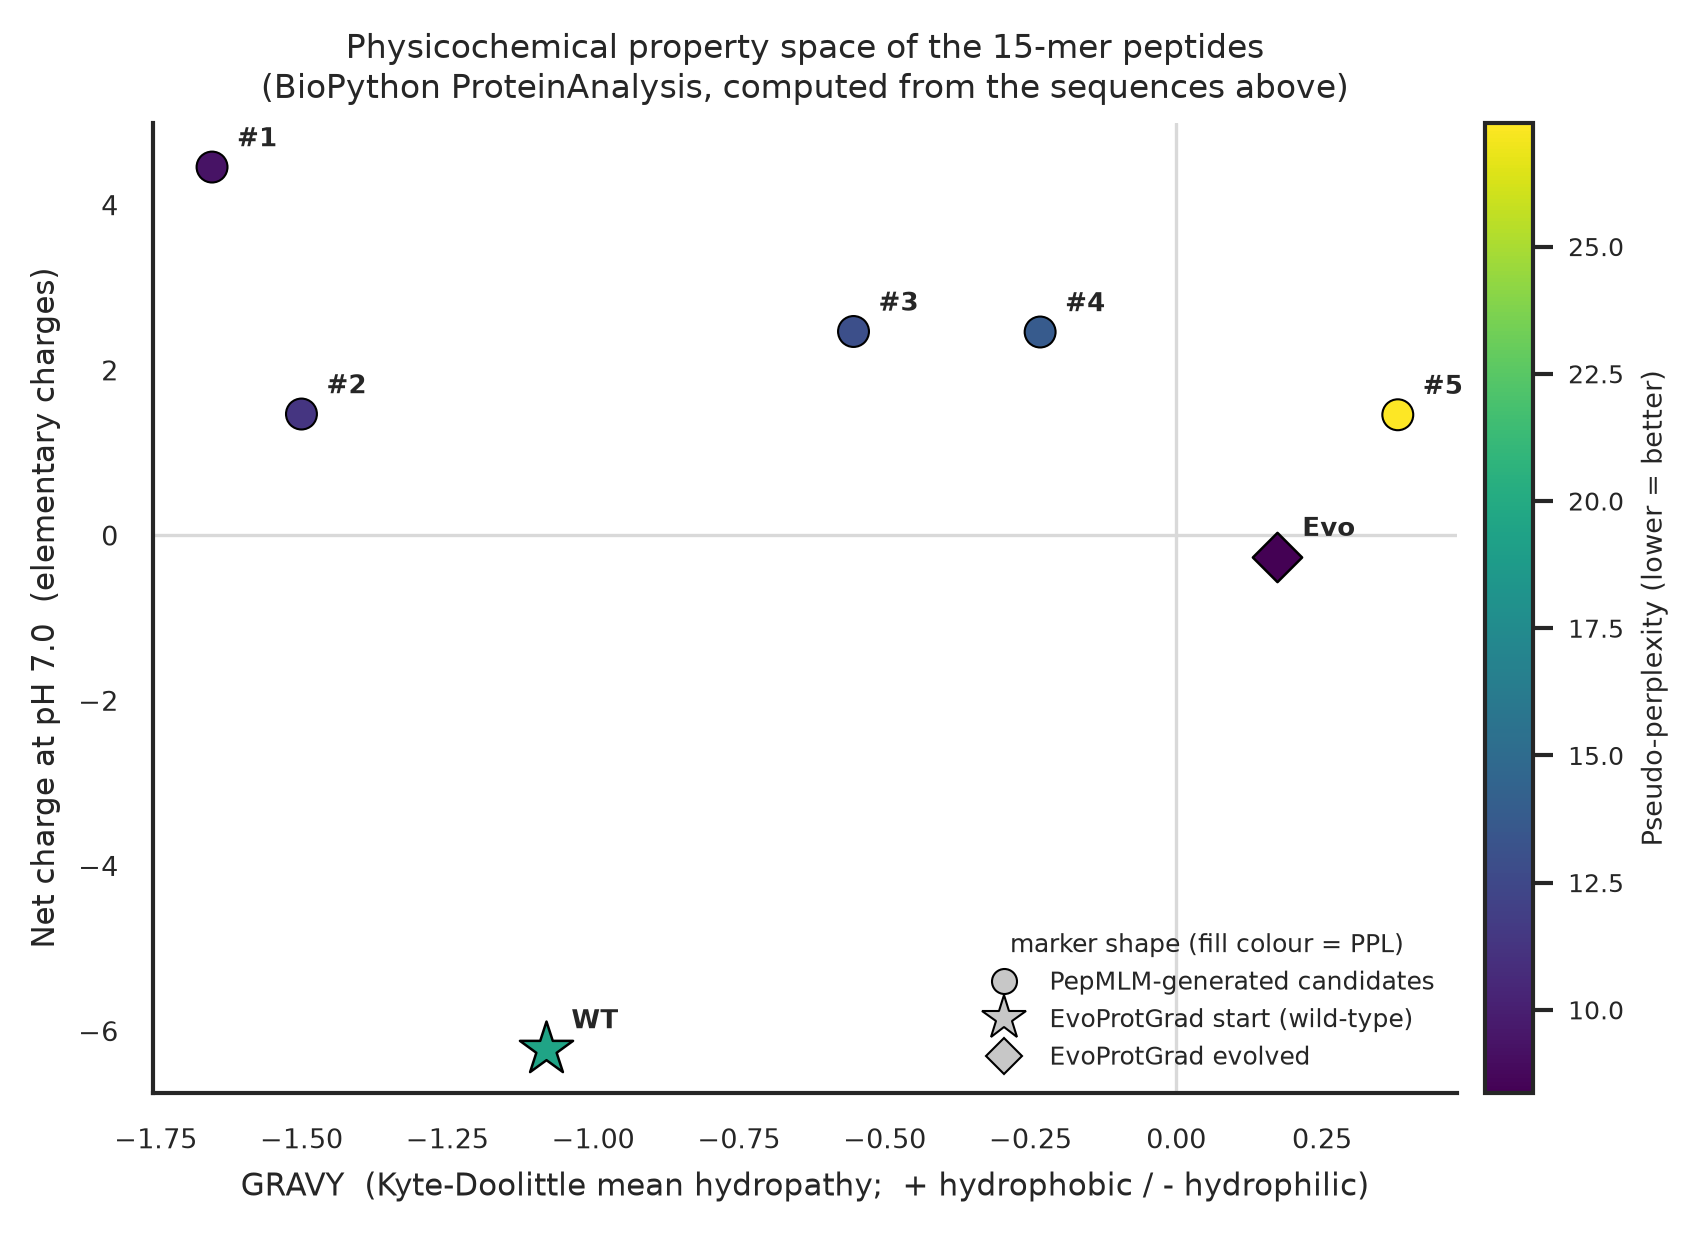


주의: 생성은 확률적(top-k sampling)이고 EvoProtGrad 도 MCMC 이므로,
      다시 실행하면 점 위치와 서열이 달라집니다. 경향(cluster 위치)만 해석하세요.


In [16]:
# === Figure 7. property space of the candidates (all values are computed, none assumed) ===
from Bio.SeqUtils.ProtParam import ProteinAnalysis

def peptide_props(seq):
    """GRAVY (Kyte-Doolittle) and net charge at pH 7.0, via BioPython."""
    pa = ProteinAnalysis(seq)
    return pa.gravy(), pa.charge_at_pH(7.0)

rows = []
for i, r in rank_df.iterrows():
    s = r["Binder"]
    if set(s) <= set(AA_ORDER):
        g, q = peptide_props(s)
        rows.append((f"#{i+1}", s, g, q, float(r["Pseudo Perplexity"]), "gen"))
    else:
        print("skipped (non-standard residue):", s)

# 진화 전/후 펩타이드도 같은 척도로 — PPL 은 노트북의 compute_pseudo_perplexity 로 실제 계산
for lab, s in [("WT", evo_result["wt_peptide"]), ("Evo", evo_result["best_peptide"])]:
    if set(s) <= set(AA_ORDER):
        g, q = peptide_props(s)
        ppl = compute_pseudo_perplexity(model, tokenizer, protein_seq, s)
        rows.append((lab, s, g, q, float(ppl), lab))
        print(f"{lab:>3} peptide {s}  GRAVY={g:+.3f}  charge(pH7)={q:+.2f}  PPL={ppl:.2f}")

gx = [r[2] for r in rows if r[5] == "gen"]
gy = [r[3] for r in rows if r[5] == "gen"]
gc = [r[4] for r in rows if r[5] == "gen"]
allppl = [r[4] for r in rows]

fig, ax = plt.subplots(figsize=(6.0, 4.2))
ax.axhline(0, color="0.85", lw=0.8, zorder=0)
ax.axvline(0, color="0.85", lw=0.8, zorder=0)

sc = ax.scatter(gx, gy, c=gc, cmap="viridis", s=55, edgecolor="black", lw=0.5,
                vmin=min(allppl), vmax=max(allppl), zorder=3)
for lab, s, g, q, ppl, kind in rows:
    if kind == "WT":
        ax.scatter([g], [q], marker="*", s=180, c=[ppl], cmap="viridis",
                   vmin=min(allppl), vmax=max(allppl), edgecolor="black", lw=0.6,
                   zorder=4)
    elif kind == "Evo":
        ax.scatter([g], [q], marker="D", s=70, c=[ppl], cmap="viridis",
                   vmin=min(allppl), vmax=max(allppl), edgecolor="black", lw=0.6,
                   zorder=4)
    ax.annotate(lab, (g, q), textcoords="offset points", xytext=(6, 5),
                fontsize=6.2, fontweight="bold")

cb = fig.colorbar(sc, ax=ax, fraction=0.045, pad=0.02)
cb.set_label("Pseudo-perplexity (lower = better)", fontsize=6.5)
cb.ax.tick_params(labelsize=6)

ax.set_xlabel("GRAVY  (Kyte-Doolittle mean hydropathy;  + hydrophobic / - hydrophilic)")
ax.set_ylabel("Net charge at pH 7.0  (elementary charges)")
ax.set_title("Physicochemical property space of the 15-mer peptides\n"
             "(BioPython ProteinAnalysis, computed from the sequences above)")
# 범례는 "모양"만 설명합니다 (색은 위 컬러바 = PPL).
from matplotlib.lines import Line2D
shape_handles = [
    Line2D([], [], ls="none", marker="o", ms=6.0, mfc="0.78", mec="black", mew=0.5,
           label="PepMLM-generated candidates"),
    Line2D([], [], ls="none", marker="*", ms=11.0, mfc="0.78", mec="black", mew=0.5,
           label="EvoProtGrad start (wild-type)"),
    Line2D([], [], ls="none", marker="D", ms=6.0, mfc="0.78", mec="black", mew=0.5,
           label="EvoProtGrad evolved"),
]
ax.legend(handles=shape_handles, frameon=False, loc="best", fontsize=6,
          title="marker shape (fill colour = PPL)", title_fontsize=6)
plt.show()

print("\n주의: 생성은 확률적(top-k sampling)이고 EvoProtGrad 도 MCMC 이므로,")
print("      다시 실행하면 점 위치와 서열이 달라집니다. 경향(cluster 위치)만 해석하세요.")


## 6. 한계와 주의

- **pseudo-perplexity 는 결합력이 아니다.** PPL 은 "ESM-2 가 보기에 단백질스러운가"를 재는
  언어모델 지표일 뿐, Kd·IC50 과 직접 대응하지 않는다. 이 노트북은 결합을 예측하지 않았다.
- **결합 부위를 모른다.** PepMLM 은 표적 서열 전체를 문맥으로 볼 뿐, 촉매 포켓이나 알로스테릭
  자리를 지정해 주지 않는다. 생성된 15-mer 가 PDE5A의 어디에 붙는지는 이 실습으로 알 수 없다.
- **결과가 실행마다 달라진다.** 생성은 top-k 샘플링(확률적)이고 EvoProtGrad 는 MCMC 다.
  본문의 서열·수치와 여러분의 실행 결과는 다르며, 경향만 해석해야 한다.
- **EvoProtGrad 의 점수도 모델 점수다.** Product-of-Experts 점수를 올린 것은 8M 짜리 작은
  ESM-2 전문가 모델을 만족시켰다는 뜻이지, 더 좋은 결합자가 되었다는 뜻이 아니다.
- **합성 가능성·안정성·면역원성은 전혀 보지 않았다.** 그림 7의 GRAVY·순전하는 계산값일 뿐이며,
  실제 검증에는 합성 후 결합·열안정성 실험이 필요하다.


## 7. 다음 실습

- [`t111_esm3_protein_design.ipynb`](https://github.com/fourmodern/2026_aidrugdiscovery/blob/main/Day06_LLM_Agent/t111_esm3_protein_design.ipynb)
  — 같은 표적 맥락에서 **ESM3**(서열 + 구조 + 기능 멀티모달)로 넘어간다. 여기서는 못 했던
  "설계한 서열의 구조를 바로 예측하고 신뢰도(pLDDT)로 검증하는" 단계를 해 본다.
- [`t042_molt5.ipynb`](https://github.com/fourmodern/2026_aidrugdiscovery/blob/main/Day06_LLM_Agent/t042_molt5.ipynb)
  — 같은 "생성 모델의 출력은 반드시 검증한다"는 문제의식을 **분자(SMILES)** 쪽에서 반복한다.
- [`t050_simple-local-rag.ipynb`](https://github.com/fourmodern/2026_aidrugdiscovery/blob/main/Day06_LLM_Agent/t050_simple-local-rag.ipynb)
  — 모델의 주장을 **문헌 근거**에 묶는 RAG 파이프라인.
